# EDA - Ozon E-Cup 2026

## 1. Задача

Предсказать суммарный GMV каждого пользователя за 30 дней после конца обучающего окна.

| Параметр | Значение |
| --- | --- |
| История | 2025-01-01 ... 2026-02-13 |
| Целевое окно | 2026-02-14 ... 2026-03-15 |
| Пользователей | 250 000 |
| Ответ | csv с колонками `user_id`, `predict` |
| Лидерборд | public 20% (50000) / private 80% (200000) |

Метрика - RMSLE, отрицательные предсказания зануляются:

$$
RMSLE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( \log(1 + y_i) - \log(1 + \max(0, p_i)) \right)^2}
$$

## 2. Подготовка

In [1]:
! pip install -q dotenv matplotlib nbformat numpy plotly polars seaborn

In [2]:
from datetime import date, timedelta
from dotenv import load_dotenv
from os import getenv
from plotly.subplots import make_subplots

import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import polars as pl
import seaborn as sns

In [ ]:
pio.renderers.default = "notebook"
pio.templates.default = "plotly_white"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 300

pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_width_chars(200)

DATA_PATH = "data/train.parquet"

horizon_days = 30
target_start = date(2026, 2, 14)
target_end = date(2026, 3, 15)
n_users_expected = 250_000
public_users = 50_000

CAT = sns.color_palette("Set2", 8)
SEQ = sns.color_palette("Blues", 7)
GREY = "gray"
cmap_seq = sns.color_palette("Blues", as_cmap=True)
cmap_div = sns.color_palette("RdBu_r", as_cmap=True)

In [4]:
load_dotenv()

True

In [5]:
vps_ip = getenv("VPS_IP_ADRESS")

In [6]:
! curl -L --create-dirs -o "{DATA_PATH}" "https://{vps_ip}/files/total.parquet"

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
100 171.8M 100 171.8M   0      0  1.21M      0   02:21   02:21          1.15M


In [7]:
flag_cols = [
    "search",
    "cat",
    "has_search_to_cart",
    "has_search_to_ord",
    "has_cat_to_cart",
    "has_cat_to_ord",
]
count_cols = [
    "search_to_cart",
    "search_to_ord",
    "cat_to_cart",
    "cat_to_ord",
    "to_cart",
    "to_ord",
    "searches",
]
money_cols = ["gmv_search", "gmv_cat", "gmv"]
num_cols = flag_cols + count_cols + money_cols

df = (
    pl.scan_parquet(DATA_PATH)
    .with_columns(
        pl.col("user_id").cast(pl.Int32),
        *[pl.col(c).cast(pl.Int8) for c in flag_cols],
        *[pl.col(c).cast(pl.Int16) for c in count_cols],
    )
    .collect()
)

print(f"rows = {df.height:,} | cols = {df.width} | in-memory = {df.estimated_size('mb'):,.0f} MB")
df.head(8)

rows = 30,631,006 | cols = 18 | in-memory = 1,519 MB


event_date,user_id,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches
date,i32,i8,i8,i8,i8,i8,i8,i16,i16,i16,i16,f64,f64,i16,i16,f64,i16
2025-06-16,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,2
2025-06-22,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-08-08,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1
2025-08-18,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-08-23,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1
2025-10-22,2,1,0,1,0,0,0,3,0,0,0,0.0,0.0,3,0,0.0,5
2025-10-23,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-11-09,2,1,0,1,0,0,0,4,0,0,0,0.0,0.0,4,0,0.0,1


Официальное описание полей:

- `event_date` - дата с 2025-01-01 по 2026-02-13
- `user_id` - идентификатор пользователя
- `search` - флаг пользования Поиском (0 или 1)
- `cat` - флаг пользования Каталогом (0 или 1)
- `has_search_to_cart` - флаг переноса товара в корзину при пользовании Поиском (0 или 1)
- `has_search_to_ord` - флаг покупки товара при пользовании Поиском (0 или 1)
- `has_cat_to_cart` - флаг переноса товара в корзину при пользовании Каталогом (0 или 1)
- `has_cat_to_ord` - флаг покупки товара при пользовании Каталогом (0 или 1)
- `search_to_cart` - число добавленных в корзину товаров при пользовании Поиском
- `search_to_ord` - число купленных товаров при пользовании Поиском
- `cat_to_cart` - число добавленных в корзину товаров при пользовании Каталогом
- `cat_to_ord` - число купленных товаров при пользовании Каталогом
- `gmv_search` - суммарная стоимость купленных товаров при пользовании Поиском
- `gmv_cat` - суммарная стоимость купленных товаров при пользовании Каталогом
- `to_cart` - суммарное число добавленных в корзину товаров
- `to_ord` - суммарное число купленных товаров
- `gmv` - суммарная стоимость купленных товаров
- `searches` - суммарное число поисковых запросов

Одна строка - один пользователь за один день, в который он был активен.


## 3. Структура датасета

In [8]:
all_dates: list[date] = df["event_date"].unique().sort().to_list()
d_min, d_max = all_dates[0], all_dates[-1]
n_users = df["user_id"].n_unique()
n_dates = len(all_dates)
n_keys = df.select("user_id", "event_date").n_unique()

pl.DataFrame(
    {
        "metric": [
            "rows",
            "unique (user_id, event_date)",
            "duplicated keys",
            "users",
            "dates",
            "date range",
            "full grid cells",
            "grid density",
            "null values",
        ],
        "value": [
            f"{df.height:,}",
            f"{n_keys:,}",
            f"{df.height - n_keys:,}",
            f"{n_users:,}",
            f"{n_dates:,}",
            f"{d_min} .. {d_max}",
            f"{n_users * n_dates:,}",
            f"{df.height / (n_users * n_dates):.1%}",
            f"{df.null_count().to_numpy().sum():,}",
        ],
    }
)

metric,value
str,str
"""rows""","""30,631,006"""
"""unique (user_id, event_date)""","""30,631,006"""
"""duplicated keys""","""0"""
"""users""","""250,000"""
"""dates""","""409"""
"""date range""","""2025-01-01 .. 2026-02-13"""
"""full grid cells""","""102,250,000"""
"""grid density""","""30.0%"""
"""null values""","""0"""


In [9]:
identity_rules = {
    "gmv == gmv_search + gmv_cat": (pl.col("gmv") - pl.col("gmv_search") - pl.col("gmv_cat")).abs()
    < 1e-9,
    "to_cart == search_to_cart + cat_to_cart": pl.col("to_cart")
    == pl.col("search_to_cart") + pl.col("cat_to_cart"),
    "to_ord == search_to_ord + cat_to_ord": pl.col("to_ord")
    == pl.col("search_to_ord") + pl.col("cat_to_ord"),
    "search == (searches > 0)": (pl.col("search") > 0) == (pl.col("searches") > 0),
    "has_search_to_cart == (search_to_cart > 0)": (pl.col("has_search_to_cart") > 0)
    == (pl.col("search_to_cart") > 0),
    "has_search_to_ord == (search_to_ord > 0)": (pl.col("has_search_to_ord") > 0)
    == (pl.col("search_to_ord") > 0),
    "has_cat_to_cart == (cat_to_cart > 0)": (pl.col("has_cat_to_cart") > 0)
    == (pl.col("cat_to_cart") > 0),
    "has_cat_to_ord == (cat_to_ord > 0)": (pl.col("has_cat_to_ord") > 0)
    == (pl.col("cat_to_ord") > 0),
    "(gmv > 0) == (to_ord > 0)": (pl.col("gmv") > 0) == (pl.col("to_ord") > 0),
    "(gmv_search > 0) == (search_to_ord > 0)": (pl.col("gmv_search") > 0)
    == (pl.col("search_to_ord") > 0),
    "(gmv_cat > 0) == (cat_to_ord > 0)": (pl.col("gmv_cat") > 0) == (pl.col("cat_to_ord") > 0),
    "cat == (cat_to_cart + cat_to_ord > 0)": (pl.col("cat") > 0)
    == (pl.col("cat_to_cart") + pl.col("cat_to_ord") > 0),
}

pl.DataFrame(
    {
        "rule": list(identity_rules),
        "share_holding": df.select([e.mean().alias(k) for k, e in identity_rules.items()]).row(0),
    }
).sort("share_holding")

rule,share_holding
str,f64
"""cat == (cat_to_cart + cat_to_o…",0.868145
"""gmv == gmv_search + gmv_cat""",1.0
"""to_cart == search_to_cart + ca…",1.0
"""to_ord == search_to_ord + cat_…",1.0
"""search == (searches > 0)""",1.0
"""has_search_to_cart == (search_…",1.0
"""has_search_to_ord == (search_t…",1.0
"""has_cat_to_cart == (cat_to_car…",1.0
"""has_cat_to_ord == (cat_to_ord …",1.0


Все правила, кроме последнего, выполняются на 100% строк - значит в данных много избыточности: `gmv`, `to_cart`, `to_ord` являются суммами по другим столбцам, все шесть флагов `has_*` выводятся из счётчиков, а GMV возникает **только** в дни с заказом (`gmv > 0` взаимно однозначен `to_ord > 0`).

Единственный по-настоящему независимый сигнал - `cat`. По описанию это «флаг пользования Каталогом», и он совпадает с `cat_to_cart + cat_to_ord > 0` лишь на 86.8% строк: заход в каталог фиксируется и тогда, когда он не привёл ни к переносу в корзину, ни к заказу.

## 4. Базовые показатели

In [10]:
profile = pl.DataFrame(
    {
        "column": num_cols,
        "dtype": [str(df.schema[c]) for c in num_cols],
        "n_unique": df.select([pl.col(c).n_unique() for c in num_cols]).row(0),
        "zero_share": df.select([(pl.col(c) == 0).mean() for c in num_cols]).row(0),
        "mean": df.select([pl.col(c).mean().cast(pl.Float64) for c in num_cols]).row(0),
        "p99": df.select([pl.col(c).quantile(0.99).cast(pl.Float64) for c in num_cols]).row(0),
        "max": df.select([pl.col(c).max().cast(pl.Float64) for c in num_cols]).row(0),
    }
)
profile

column,dtype,n_unique,zero_share,mean,p99,max
str,str,i64,f64,f64,f64,f64
"""search""","""Int8""",2,0.193419,0.806581,1.0,1.0
"""cat""","""Int8""",2,0.844353,0.155647,1.0,1.0
"""has_search_to_cart""","""Int8""",2,0.651895,0.348105,1.0,1.0
"""has_search_to_ord""","""Int8""",2,0.852632,0.147368,1.0,1.0
"""has_cat_to_cart""","""Int8""",2,0.959826,0.040174,1.0,1.0
"""has_cat_to_ord""","""Int8""",2,0.989178,0.010822,1.0,1.0
"""search_to_cart""","""Int16""",240,0.651895,0.962445,10.0,816.0
"""search_to_ord""","""Int16""",74,0.852632,0.248017,4.0,138.0
"""cat_to_cart""","""Int16""",158,0.959826,0.080318,2.0,1535.0


In [11]:
zero_df = profile.select("column", "zero_share").sort("zero_share")

fig = px.bar(
    zero_df,
    x="zero_share",
    y="column",
    orientation="h",
    text_auto=".1%",
    color_discrete_sequence=[CAT[0]],
    labels={"zero_share": "share of zero values", "column": ""},
    title="Sparsity by column (row grain = user x active day)",
)
fig.update_traces(marker_cornerradius=4, hovertemplate="%{y}<br>zeros: %{x:.2%}<extra></extra>")
fig.update_layout(height=520, xaxis_tickformat=".0%", bargap=0.35)
fig.show()

In [12]:
users = (
    df.group_by("user_id").agg(
        active_days=pl.len(),
        first_seen=pl.col("event_date").min(),
        last_seen=pl.col("event_date").max(),
        gmv=pl.col("gmv").sum(),
        gmv_search=pl.col("gmv_search").sum(),
        gmv_cat=pl.col("gmv_cat").sum(),
        orders=pl.col("to_ord").sum(),
        carts=pl.col("to_cart").sum(),
        searches=pl.col("searches").sum(),
        buy_days=(pl.col("to_ord") > 0).sum(),
    )
    .with_columns(span_days=(pl.col("last_seen") - pl.col("first_seen")).dt.total_days() + 1)
    .with_columns(
        activity_rate=pl.col("active_days") / pl.col("span_days"),
        buy_rate=pl.col("buy_days") / pl.col("active_days"),
        aov=pl.when(pl.col("orders") > 0).then(pl.col("gmv") / pl.col("orders")).otherwise(None),
    )
    .sort("user_id")
)
users.select(
    "active_days", "span_days", "activity_rate", "gmv", "orders", "carts", "searches", "buy_rate"
).describe()

statistic,active_days,span_days,activity_rate,gmv,orders,carts,searches,buy_rate
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",250000.0,250000.0,250000.0,250000.0,250000.0,250000.0,250000.0,250000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",122.524024,363.742808,0.326903,1088.406296,32.207872,127.763576,393.833904,0.128796
"""std""",87.445046,82.343232,0.208964,2303.746136,63.536926,218.719647,549.407268,0.111247
"""min""",3.0,33.0,0.01005,0.0,0.0,0.0,0.0,0.0
"""25%""",51.0,374.0,0.156479,73.760933,3.0,20.0,92.0,0.044776
"""50%""",102.0,400.0,0.282051,388.193007,14.0,57.0,219.0,0.105263
"""75%""",178.0,406.0,0.461916,1210.38622,38.0,148.0,488.0,0.186441
"""max""",409.0,409.0,1.0,123075.702541,3359.0,16563.0,25723.0,1.0


## 5. Активность пользователей

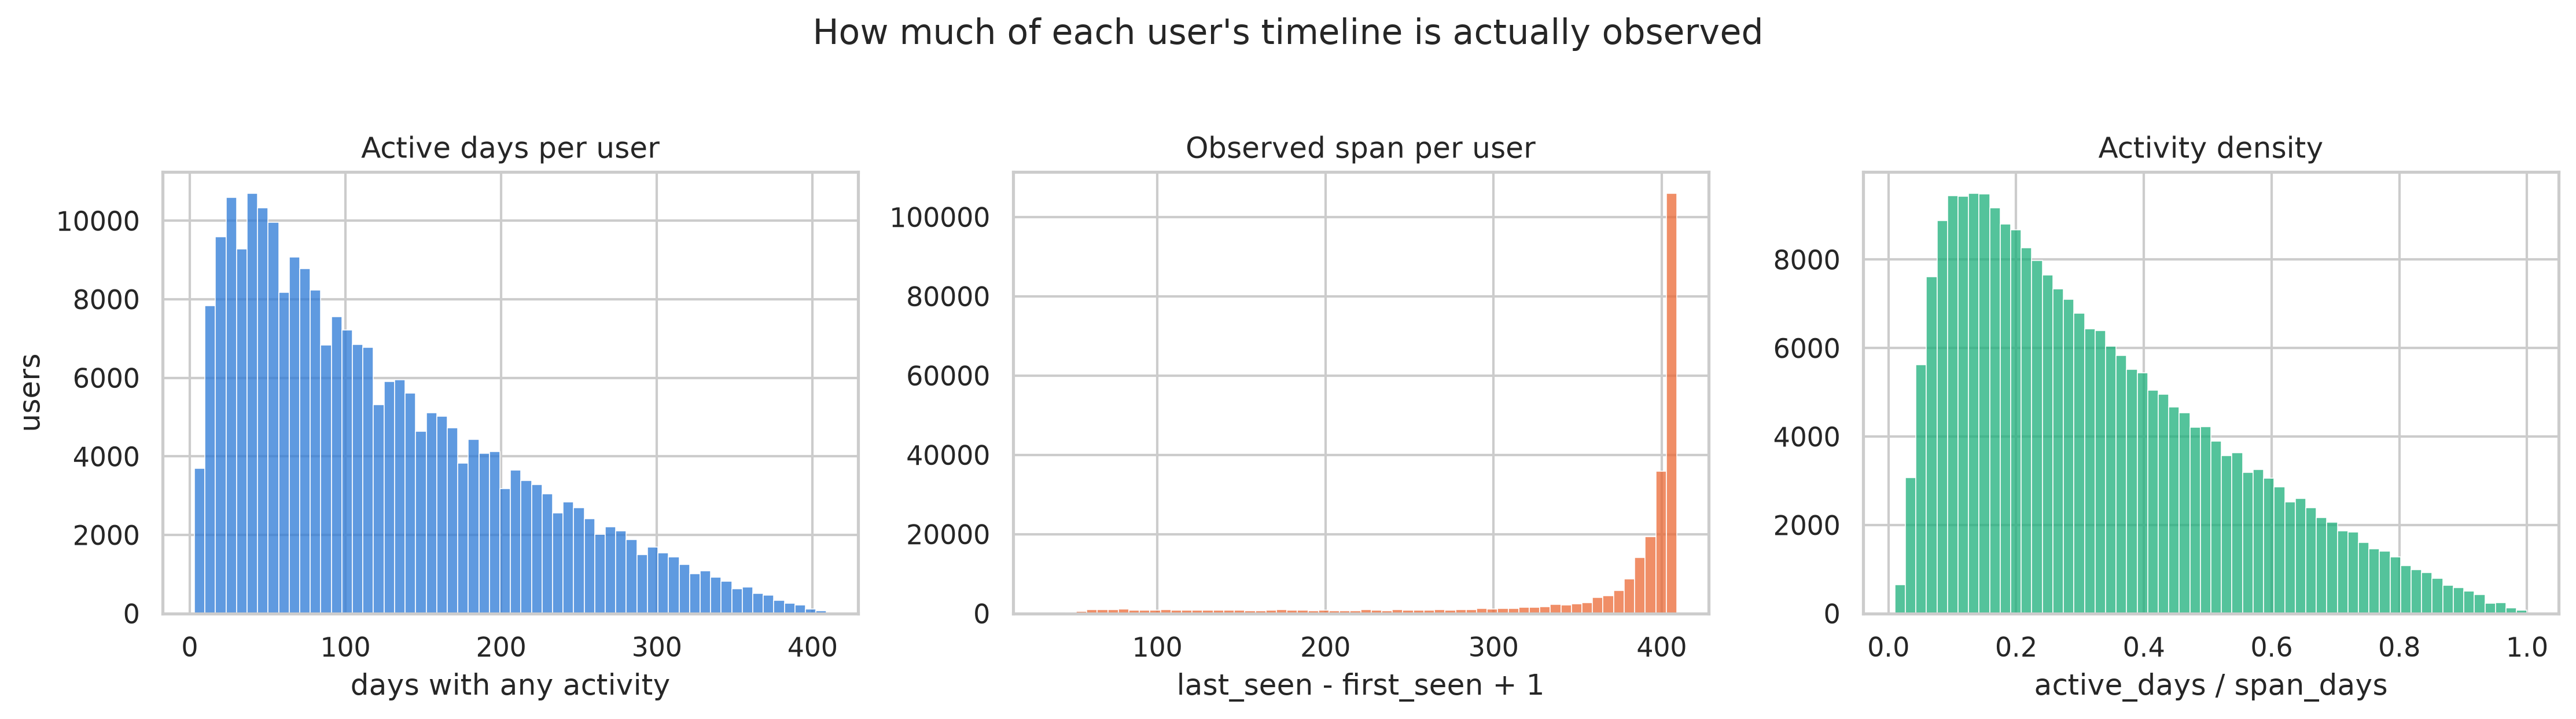

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(users["active_days"].to_numpy(), bins=60, color=CAT[0], ax=axes[0])
axes[0].set(title="Active days per user", xlabel="days with any activity", ylabel="users")
sns.histplot(users["span_days"].to_numpy(), bins=60, color=CAT[1], ax=axes[1])
axes[1].set(title="Observed span per user", xlabel="last_seen - first_seen + 1", ylabel="")
sns.histplot(users["activity_rate"].to_numpy(), bins=60, color=CAT[2], ax=axes[2])
axes[2].set(title="Activity density", xlabel="active_days / span_days", ylabel="")
fig.suptitle("How much of each user's timeline is actually observed", y=1.03)
plt.tight_layout()
plt.show()

In [14]:
edges = pl.concat(
    [
        users.group_by("first_seen")
        .len()
        .rename({"first_seen": "day", "len": "n_users"})
        .with_columns(kind=pl.lit("first seen")),
        users.group_by("last_seen")
        .len()
        .rename({"last_seen": "day", "len": "n_users"})
        .with_columns(kind=pl.lit("last seen")),
    ]
).sort("day")

fig = px.line(
    edges,
    x="day",
    y="n_users",
    color="kind",
    color_discrete_sequence=[CAT[0], CAT[1]],
    labels={"day": "", "n_users": "users", "kind": ""},
    title="First and last observed day per user (log scale)",
)
fig.update_traces(line_width=2, hovertemplate="%{x|%Y-%m-%d}<br>%{y:,} users<extra></extra>")
fig.update_layout(height=430, yaxis_type="log", hovermode="x unified")
fig.show()

print(f"latest first_seen : {users['first_seen'].max()}")
print(f"earliest last_seen: {users['last_seen'].min()}")
print(f"minimum active days per user: {users['active_days'].min()}")

latest first_seen : 2025-12-15
earliest last_seen: 2026-01-15
minimum active days per user: 3


Ни у одного пользователя последняя активность не раньше 2026-01-15. Т. е. все 250 000 пользователей хотя бы раз активны в последние 30 дней. И ни один не появляется впервые позже 2025-12-15, значит у каждого есть минимум ~60 дней истории.

Панель отобрана по выживанию, а не случайной выборкой из базы пользователей. Всё, что видно дальше во временных разрезах, надо читать с поправкой на это.


## 6. Ежедневная динамика

In [15]:
daily = (
    df.group_by("event_date")
    .agg(
        active_users=pl.len(),
        buyers=(pl.col("to_ord") > 0).sum(),
        gmv=pl.col("gmv").sum(),
        gmv_search=pl.col("gmv_search").sum(),
        gmv_cat=pl.col("gmv_cat").sum(),
        orders=pl.col("to_ord").sum(),
        carts=pl.col("to_cart").sum(),
        searches=pl.col("searches").sum(),
    )
    .sort("event_date")
    .with_columns(
        gmv_per_active=pl.col("gmv") / pl.col("active_users"),
        buyer_rate=pl.col("buyers") / pl.col("active_users"),
        cat_gmv_share=pl.col("gmv_cat") / pl.col("gmv"),
    )
)
panels = [
    ("active_users", "Active users"),
    ("gmv", "GMV"),
    ("orders", "Orders"),
    ("searches", "Searches"),
]
daily = daily.with_columns([pl.col(c).rolling_mean(7).alias(f"{c}_r7") for c, _ in panels])
daily.tail(5)

event_date,active_users,buyers,gmv,gmv_search,gmv_cat,orders,carts,searches,gmv_per_active,buyer_rate,cat_gmv_share,active_users_r7,gmv_r7,orders_r7,searches_r7
date,u32,u32,f64,f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64
2026-02-09,95083,13874,681178.175897,634449.23589,46728.940007,23025,102333,304631,7.164037,0.145915,0.0686,93623.0,687674.559919,23551.857143,303032.142857
2026-02-10,94016,14560,734643.825357,685259.123041,49384.702315,24913,103827,305280,7.81403,0.154867,0.067223,93577.857143,693845.176873,23827.285714,303398.571429
2026-02-11,95601,14778,721942.486853,672101.261521,49841.225333,24286,103769,305713,7.551621,0.15458,0.069038,93893.571429,699640.932508,23946.571429,304256.714286
2026-02-12,94450,14598,757756.442058,707165.63084,50590.811218,24705,102427,299492,8.022832,0.154558,0.066764,93906.285714,708263.842226,24043.285714,304089.0
2026-02-13,91293,14100,750104.810944,688465.440957,61639.369986,23412,96529,285454,8.216455,0.154448,0.082174,94072.428571,720275.373607,24200.857143,304738.142857


In [16]:
fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[t for _, t in panels],
)
for i, ((col, title), color) in enumerate(
    zip(panels, [CAT[0], CAT[1], CAT[2], CAT[6]], strict=False), start=1
):
    fig.add_trace(
        go.Scatter(
            x=daily["event_date"],
            y=daily[col],
            mode="lines",
            line={"color": color, "width": 1},
            opacity=0.3,
            name=title,
            showlegend=False,
            hovertemplate="%{y:,.0f}<extra>daily</extra>",
        ),
        row=i,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=daily["event_date"],
            y=daily[f"{col}_r7"],
            mode="lines",
            line={"color": color, "width": 2},
            name=f"{title} (7d)",
            showlegend=False,
            hovertemplate="%{y:,.0f}<extra>7-day mean</extra>",
        ),
        row=i,
        col=1,
    )
fig.update_layout(
    height=940,
    hovermode="x unified",
    title_text="Daily platform dynamics - raw series with 7-day rolling mean",
)
fig.show()

In [17]:
norm = daily.select(
    "event_date",
    *[
        (pl.col(c) / pl.col(c).head(28).mean()).alias(t)
        for c, t in [
            ("active_users", "Active users"),
            ("gmv_per_active", "GMV per active user"),
            ("buyer_rate", "Buyer rate"),
        ]
    ],
).unpivot(index="event_date", variable_name="series", value_name="index")

fig = px.line(
    norm,
    x="event_date",
    y="index",
    color="series",
    color_discrete_sequence=[CAT[0], CAT[1], CAT[2]],
    labels={"event_date": "", "index": "index, first 28 days = 1.0", "series": ""},
    title="Volume growth vs per-user intensity (indexed to the first 4 weeks)",
)
fig.update_traces(line_width=1.5, hovertemplate="%{y:.2f}<extra>%{fullData.name}</extra>")
fig.add_hline(y=1.0, line_color=GREY, line_dash="dash", line_width=2)
fig.update_layout(height=430, hovermode="x unified")
fig.show()

Дневная аудитория за окно почти удваивается (из 43 тыс. в 95 тыс.), при этом GMV на активного пользователя и доля покупателей остаются плоскими.

Значит рост не поведенческий - это следствие отбора из предыдущего раздела: чем ближе день к концу окна, тем выше вероятность увидеть отобранного пользователя активным. Абсолютные объёмы за ранние месяцы занижены, и сравнивать их с поздними «в лоб» нельзя.


## 7. Сезонность

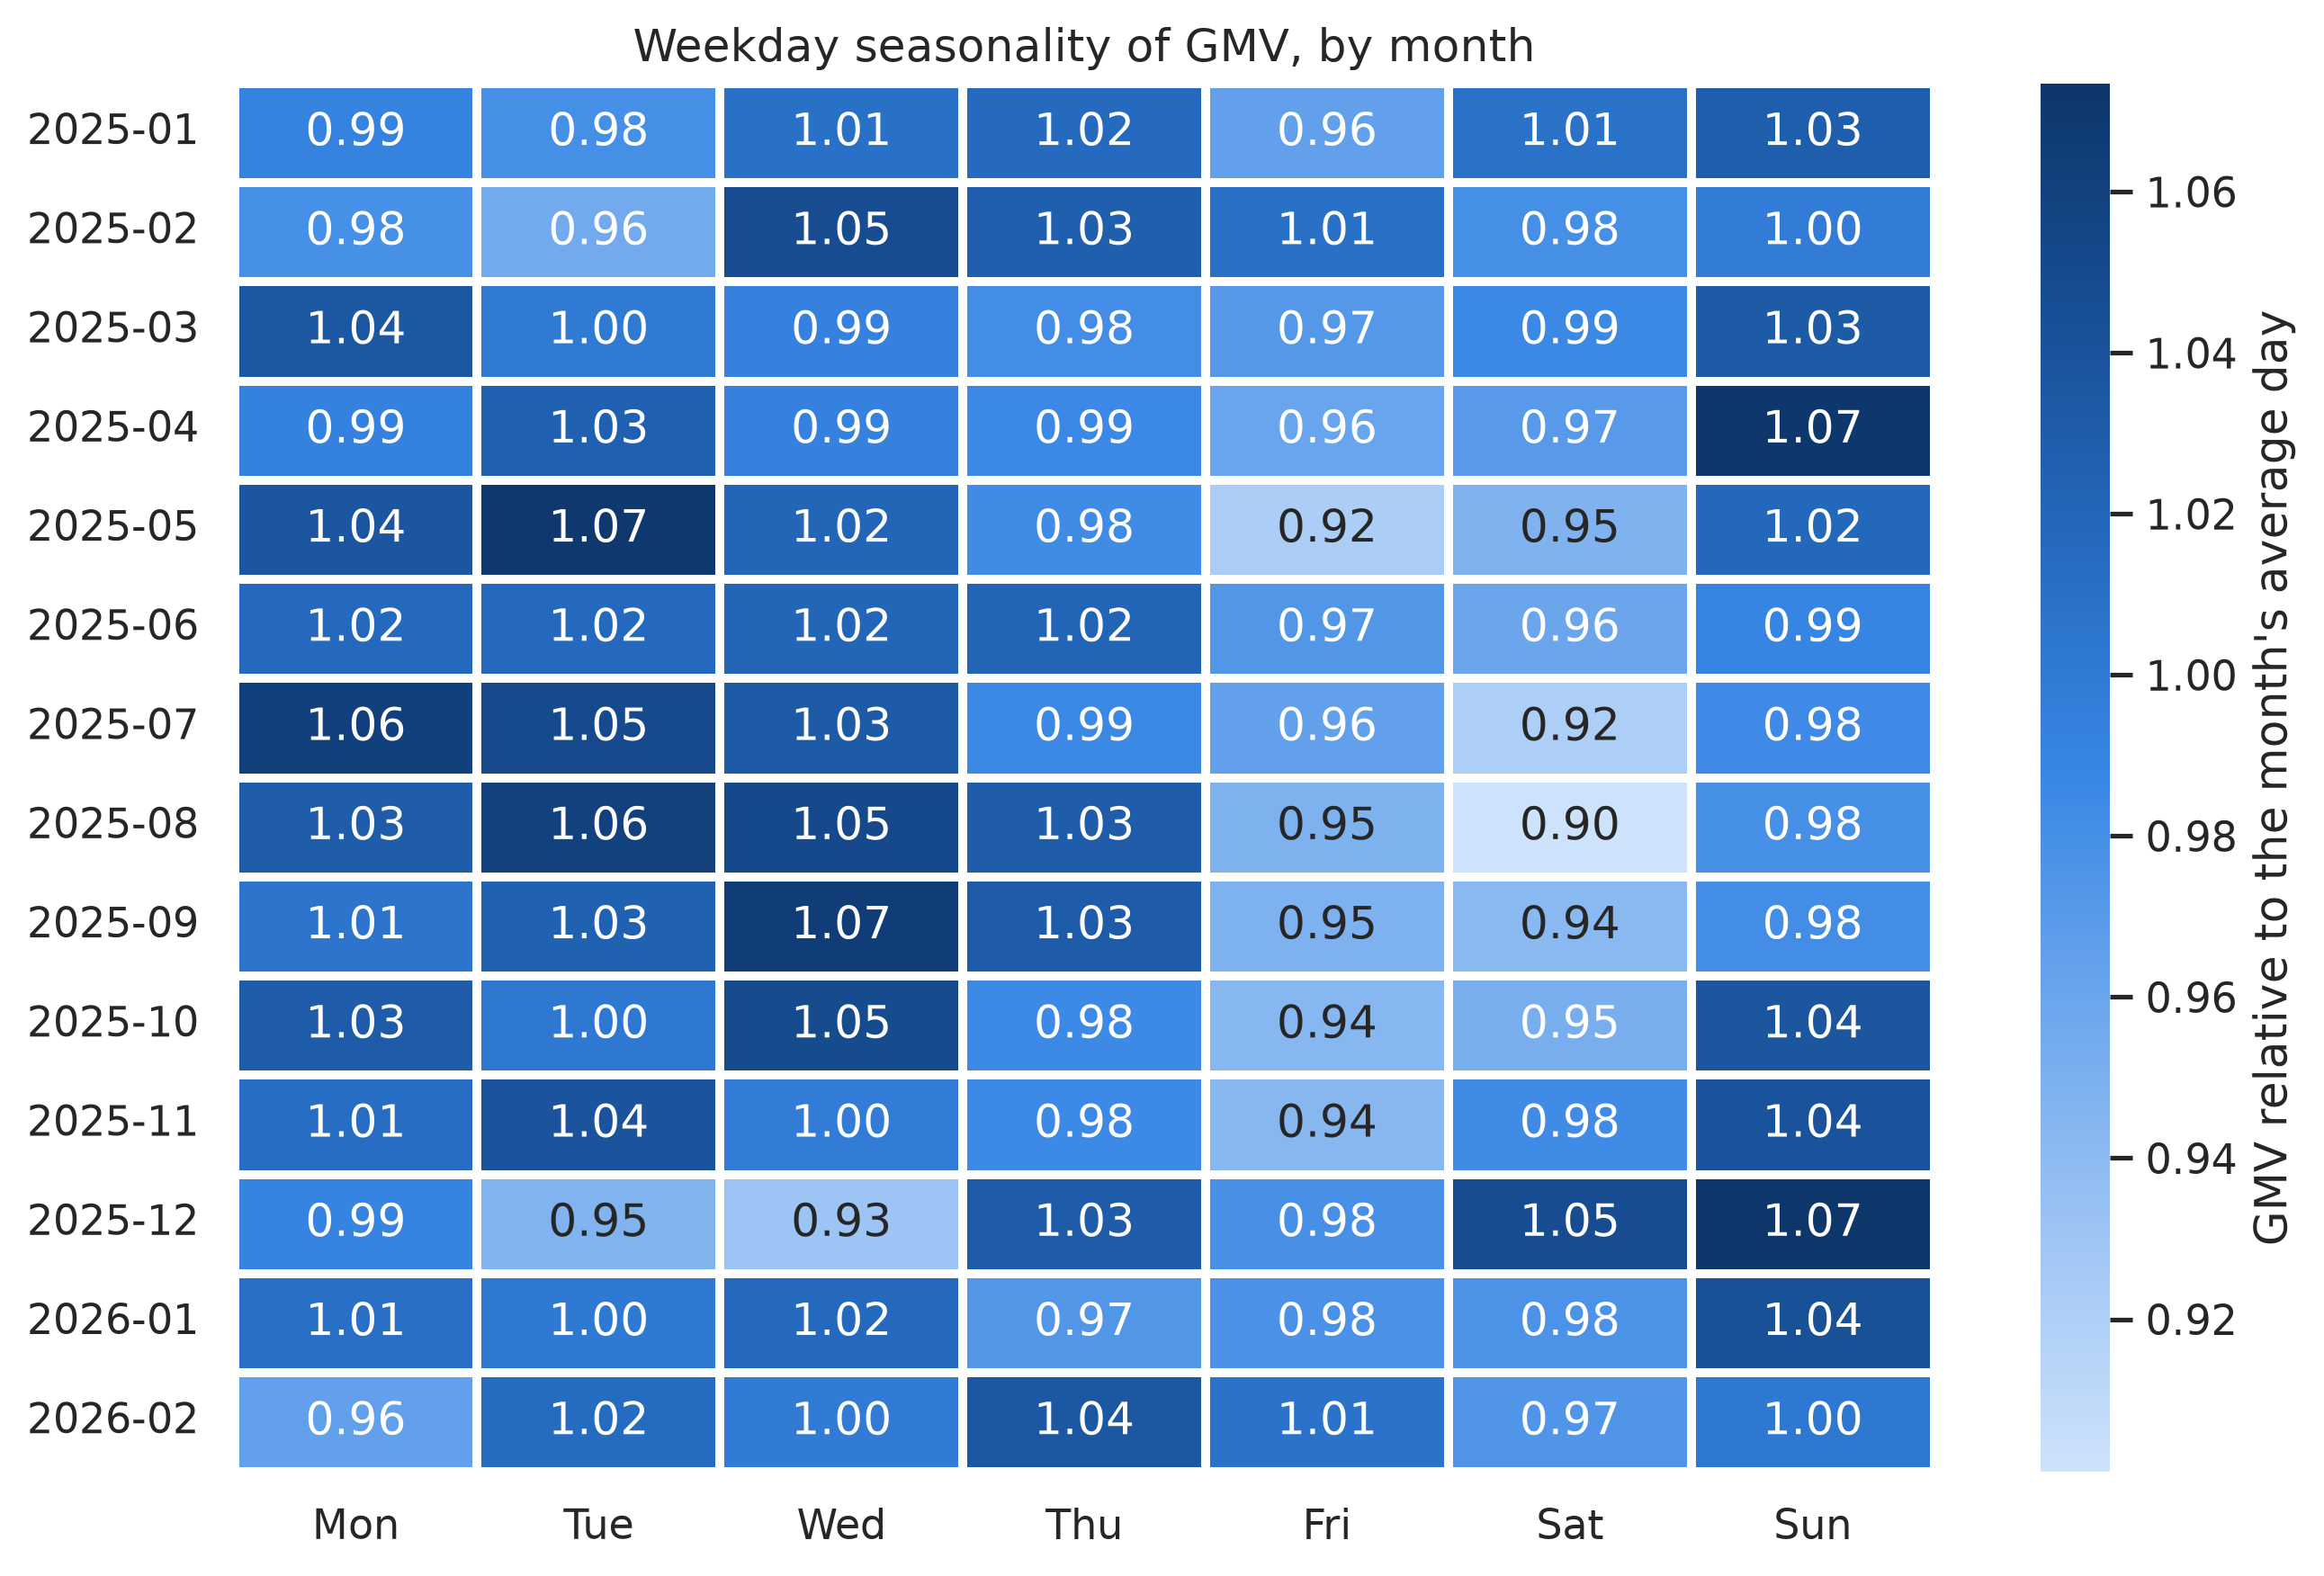

In [18]:
weekdays = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
season = daily.with_columns(
    month=pl.col("event_date").dt.strftime("%Y-%m"),
    weekday=pl.col("event_date").dt.weekday(),
)
pivot = season.pivot(on="weekday", index="month", values="gmv", aggregate_function="mean").sort(
    "month"
)
mat = pivot.select([str(i) for i in range(1, 8)]).to_numpy()
mat = mat / mat.mean(axis=1, keepdims=True)

plt.figure(figsize=(9, 6))
sns.heatmap(
    mat,
    annot=True,
    fmt=".2f",
    cmap=cmap_seq,
    xticklabels=weekdays,
    yticklabels=pivot["month"].to_list(),
    linewidths=2,
    linecolor="white",
    cbar_kws={"label": "GMV relative to the month's average day"},
)
plt.title("Weekday seasonality of GMV, by month")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [19]:
wd = (
    season.group_by("weekday")
    .agg(
        gmv=pl.col("gmv").mean(),
        active_users=pl.col("active_users").mean(),
        buyer_rate=pl.col("buyer_rate").mean(),
    )
    .sort("weekday")
    .with_columns(day=pl.Series(weekdays))
)

fig = px.bar(
    wd,
    x="day",
    y="gmv",
    text_auto=".3s",
    color_discrete_sequence=[CAT[0]],
    labels={"day": "", "gmv": "mean daily GMV"},
    title="Mean daily GMV by weekday",
)
fig.update_traces(marker_cornerradius=4, hovertemplate="%{x}<br>%{y:,.0f}<extra></extra>")
fig.update_layout(height=380, bargap=0.35)
fig.show()

extremes = pl.concat(
    [
        daily.sort("gmv", descending=True).head(7).with_columns(kind=pl.lit("peak")),
        daily.sort("gmv").head(7).with_columns(kind=pl.lit("trough")),
    ]
).select("kind", "event_date", "active_users", "gmv", "orders", "gmv_per_active")
extremes

kind,event_date,active_users,gmv,orders,gmv_per_active
str,date,u32,f64,i64,f64
"""peak""",2025-12-27,92960,1.0930e6,30849,11.758051
"""peak""",2025-12-25,96169,1.0927e6,30896,11.362423
"""peak""",2025-12-21,101903,1.0665e6,32367,10.466192
"""peak""",2025-12-26,90912,1.0457e6,29320,11.502226
"""peak""",2025-12-28,93986,1.0312e6,30122,10.972274
"""peak""",2025-12-14,103617,1.0255e6,30743,9.897134
"""peak""",2025-12-22,99558,1.0252e6,29705,10.297441
"""trough""",2025-01-01,43516,374066.469016,8827,8.596067
"""trough""",2025-01-31,56360,421771.869415,11669,7.483532


Недельные паттерны слабы и нестабильны: летом самый слабый день недели - суббота (0.90-0.92 от среднего дня месяца), а в декабре выходные становятся самыми сильными (суббота 1.05, воскресенье 1.07). Фиксированный признак «выходной/будний» здесь будет работать плохо - эффект зависит от сезона.

Календарные эффекты гораздо сильнее недельных: предпраздничный разгон 20-28 декабря, провалы 31 декабря и 1 января (-29% и -25% к скользящей медиане), 9 мая (-23%), всплеск 11 ноября (+19%, распродажа 11.11). Поэтому сравнивать 30-дневные периоды между собой нужно осторожно: окно, накрывающее конец декабря, несопоставимо с февральским.


## 8. Распределение GMV

In [20]:
gmv_rows = df["gmv"].to_numpy()
users_gmv = users["gmv"].to_numpy()
positive = gmv_rows[gmv_rows > 0]
qs = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 0.9999]

print(f"rows with gmv == 0 : {(gmv_rows == 0).mean():.2%}")
print(f"users with gmv == 0: {(users_gmv == 0).mean():.2%}")

pl.DataFrame(
    {
        "quantile": qs,
        "gmv | row with order": [float(np.quantile(positive, q)) for q in qs],
        "gmv | user total": [float(np.quantile(users_gmv, q)) for q in qs],
    }
)

rows with gmv == 0 : 84.54%
users with gmv == 0: 12.33%


quantile,gmv | row with order,gmv | user total
f64,f64,f64
0.5,23.332204,388.192308
0.75,53.685766,1210.388731
0.9,118.572121,2764.38222
0.95,196.838581,4305.052927
0.99,557.20265,9680.499806
0.999,1769.741583,24373.981374
0.9999,4436.288324,58166.485259


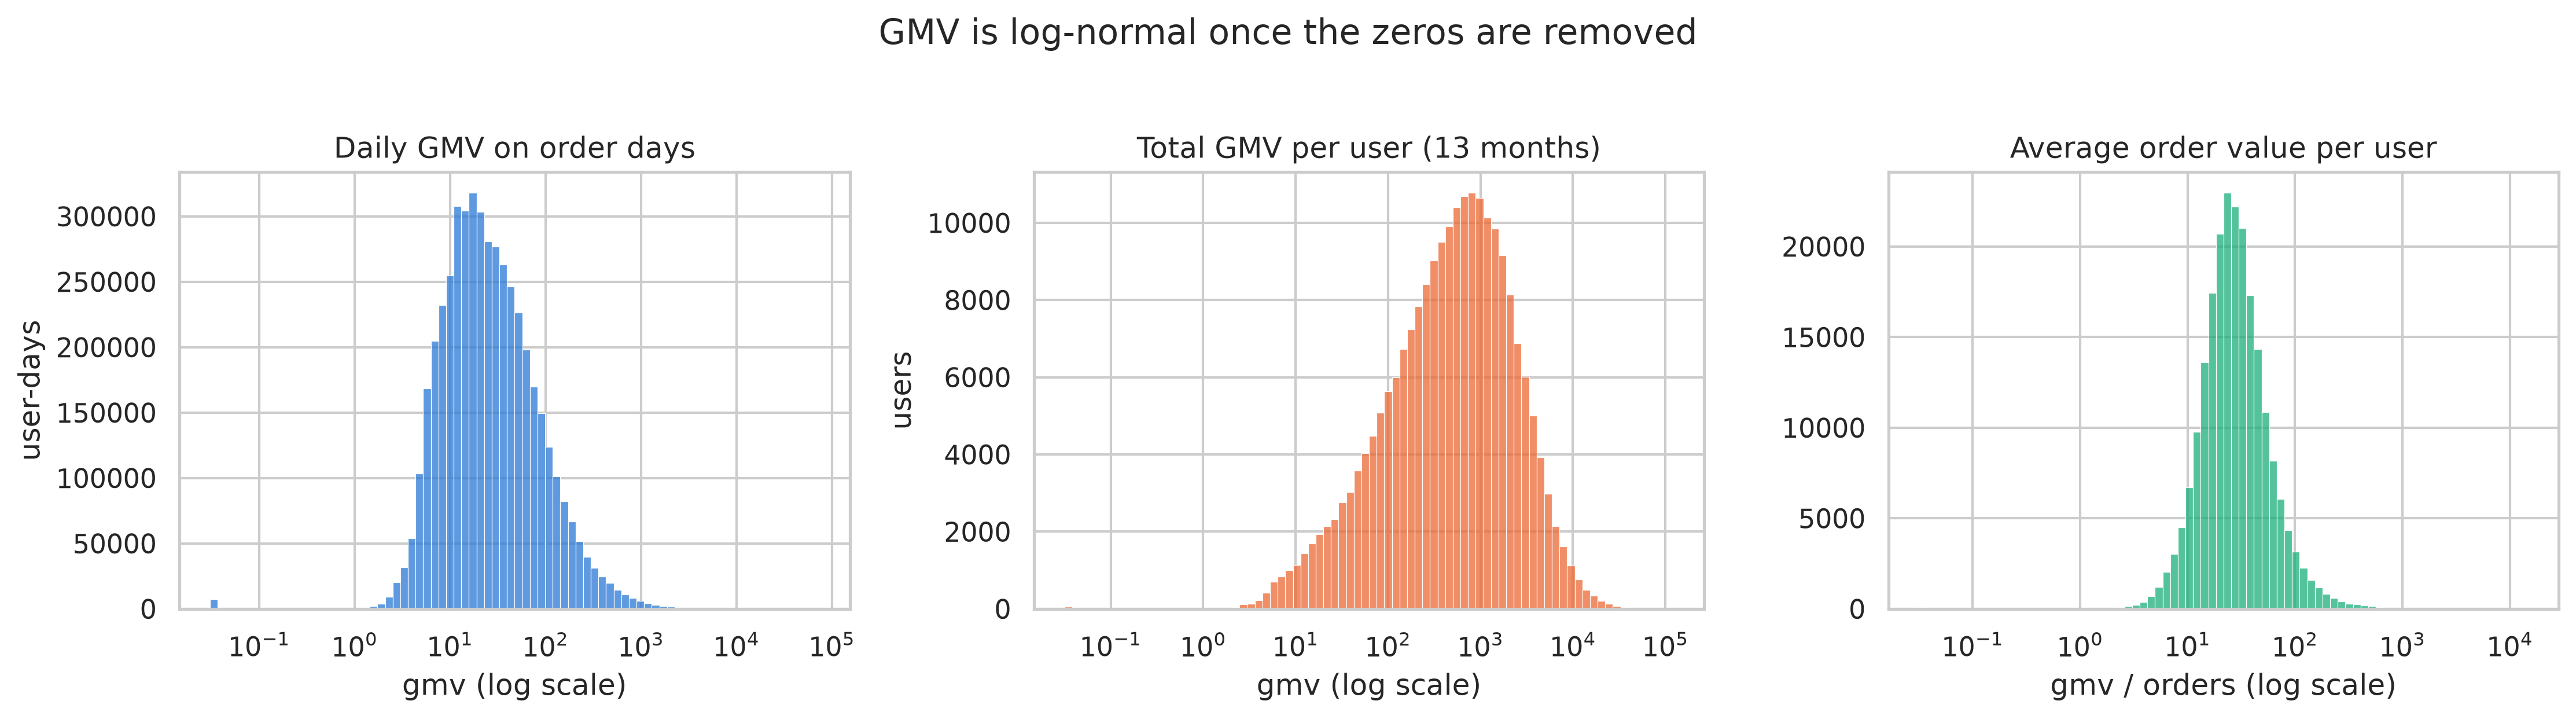

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(positive, bins=80, log_scale=True, color=CAT[0], ax=axes[0])
axes[0].set(title="Daily GMV on order days", xlabel="gmv (log scale)", ylabel="user-days")
sns.histplot(
    users.filter(pl.col("gmv") > 0)["gmv"].to_numpy(),
    bins=80,
    log_scale=True,
    color=CAT[1],
    ax=axes[1],
)
axes[1].set(title="Total GMV per user (13 months)", xlabel="gmv (log scale)", ylabel="users")
sns.histplot(
    users.filter(pl.col("orders") > 0)["aov"].to_numpy(),
    bins=80,
    log_scale=True,
    color=CAT[2],
    ax=axes[2],
)
axes[2].set(title="Average order value per user", xlabel="gmv / orders (log scale)", ylabel="")
fig.suptitle("GMV is log-normal once the zeros are removed", y=1.03)
plt.tight_layout()
plt.show()

In [22]:
g = np.sort(users_gmv)
cum = np.cumsum(g) / g.sum()
frac = np.arange(1, g.size + 1) / g.size
idx = np.unique(np.linspace(0, g.size - 1, 20_000).astype(int))
gini = float(1 - 2 * np.trapezoid(cum, frac))

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=frac[idx],
        y=cum[idx],
        mode="lines",
        name="observed GMV",
        line={"color": CAT[0], "width": 2},
        hovertemplate="bottom %{x:.0%} of users<br>hold %{y:.1%} of GMV<extra></extra>",
    )
)
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="perfect equality",
        line={"color": GREY, "width": 2, "dash": "dash"},
        hoverinfo="skip",
    )
)
fig.update_layout(
    height=460,
    title=f"Lorenz curve of user GMV - Gini = {gini:.3f}",
    xaxis={"title": "cumulative share of users", "tickformat": ".0%"},
    yaxis={"title": "cumulative share of GMV", "tickformat": ".0%"},
    legend={"x": 0.02, "y": 0.98},
)
fig.show()

ranked_gmv = g[::-1]
pl.DataFrame(
    {
        "top share of users": ["1%", "5%", "10%", "20%", "50%"],
        "share of total GMV": [
            ranked_gmv[: int(g.size * p)].sum() / g.sum() for p in [0.01, 0.05, 0.1, 0.2, 0.5]
        ],
    }
)

top share of users,share of total GMV
str,f64
"""1%""",0.149265
"""5%""",0.373081
"""10%""",0.53019
"""20%""",0.718559
"""50%""",0.948487


## 9. Search vs Category

In [23]:
crosstab = (
    df.group_by("search", "cat")
    .agg(
        rows=pl.len(),
        row_share=pl.len() / df.height,
        gmv_total=pl.col("gmv").sum(),
        gmv_per_day=pl.col("gmv").mean(),
        order_day_rate=(pl.col("to_ord") > 0).mean(),
        mean_searches=pl.col("searches").mean(),
    )
    .sort("search", "cat")
)
crosstab

search,cat,rows,row_share,gmv_total,gmv_per_day,order_day_rate,mean_searches
i8,i8,u32,f64,f64,f64,f64,f64
0,0,4667981,0.152394,1.4740e6,0.315778,0.007138,0.0
0,1,1256650,0.041025,3.8434e6,3.058472,0.045702,0.0
1,0,21195391,0.691959,2.0592e8,9.715533,0.178719,3.637341
1,1,3510984,0.114622,6.0860e7,17.33405,0.244415,6.084796


In [24]:
channels = daily.select("event_date", "gmv_search", "gmv_cat").unpivot(
    index="event_date", variable_name="channel", value_name="gmv"
)

fig = px.area(
    channels,
    x="event_date",
    y="gmv",
    color="channel",
    color_discrete_sequence=[CAT[0], CAT[1]],
    labels={"event_date": "", "gmv": "daily GMV", "channel": ""},
    title="Daily GMV split by attribution channel",
)
fig.update_traces(line_width=0, hovertemplate="%{y:,.0f}<extra>%{fullData.name}</extra>")
fig.update_layout(height=430, hovermode="x unified")
fig.show()

fig = px.line(
    daily,
    x="event_date",
    y="cat_gmv_share",
    color_discrete_sequence=[CAT[1]],
    labels={"event_date": "", "cat_gmv_share": "category share of GMV"},
    title="Category channel share of GMV over time",
)
fig.update_traces(line_width=1.5, hovertemplate="%{x|%Y-%m-%d}<br>%{y:.1%}<extra></extra>")
fig.update_layout(height=360, yaxis_tickformat=".0%")
fig.show()

## 10. Коневерсия

In [25]:
stages = pl.DataFrame(
    {
        "stage": ["active day", "searched", "added to cart", "placed order"],
        "user_days": [
            df.height,
            df.select((pl.col("searches") > 0).sum()).item(),
            df.select((pl.col("to_cart") > 0).sum()).item(),
            df.select((pl.col("to_ord") > 0).sum()).item(),
        ],
    }
)

fig = px.funnel(
    stages,
    x="user_days",
    y="stage",
    color_discrete_sequence=[CAT[0]],
    labels={"user_days": "user-days", "stage": ""},
    title="Same-day funnel across all 30.6M user-days",
)
fig.update_layout(height=380)
fig.show()

conv = daily.select(
    "event_date",
    (pl.col("carts") / pl.col("searches")).alias("cart per search"),
    (pl.col("orders") / pl.col("carts")).alias("order per cart"),
    (pl.col("orders") / pl.col("searches")).alias("order per search"),
).unpivot(index="event_date", variable_name="rate", value_name="value")

fig = px.line(
    conv,
    x="event_date",
    y="value",
    color="rate",
    color_discrete_sequence=[CAT[0], CAT[1], CAT[2]],
    labels={"event_date": "", "value": "conversion rate", "rate": ""},
    title="Conversion rates over time",
)
fig.update_traces(line_width=1.5, hovertemplate="%{y:.3f}<extra>%{fullData.name}</extra>")
fig.update_layout(height=430, hovermode="x unified")
fig.show()

## 11. Интенсивность за день

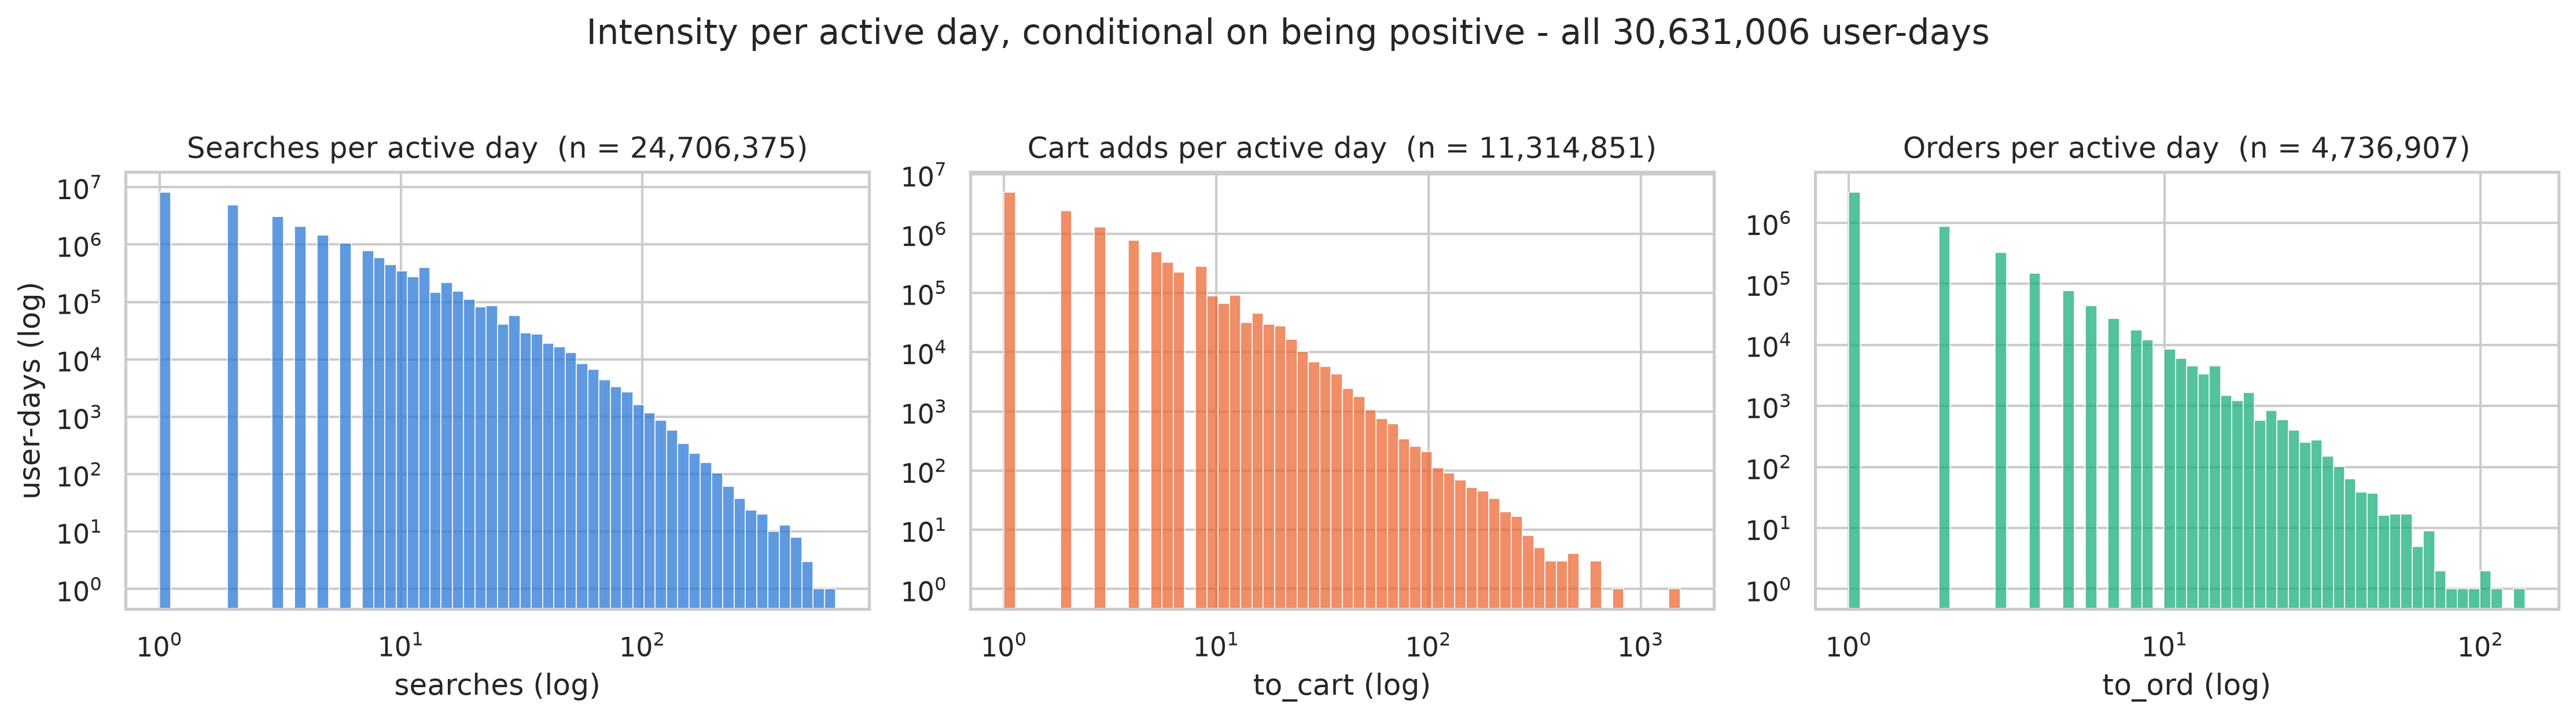

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color, title in zip(
    axes,
    ["searches", "to_cart", "to_ord"],
    [CAT[0], CAT[1], CAT[2]],
    ["Searches per active day", "Cart adds per active day", "Orders per active day"],
    strict=False,
):
    vals = df.select(col).filter(pl.col(col) > 0).to_series().to_numpy()
    sns.histplot(vals, bins=60, log_scale=True, color=color, ax=ax)
    ax.set_yscale("log")
    ax.set(
        title=f"{title}  (n = {vals.size:,})",
        xlabel=f"{col} (log)",
        ylabel="user-days (log)" if col == "searches" else "",
    )
fig.suptitle(
    f"Intensity per active day, conditional on being positive - all {df.height:,} user-days", y=1.03
)
plt.tight_layout()
plt.show()

## 12. Корреляция

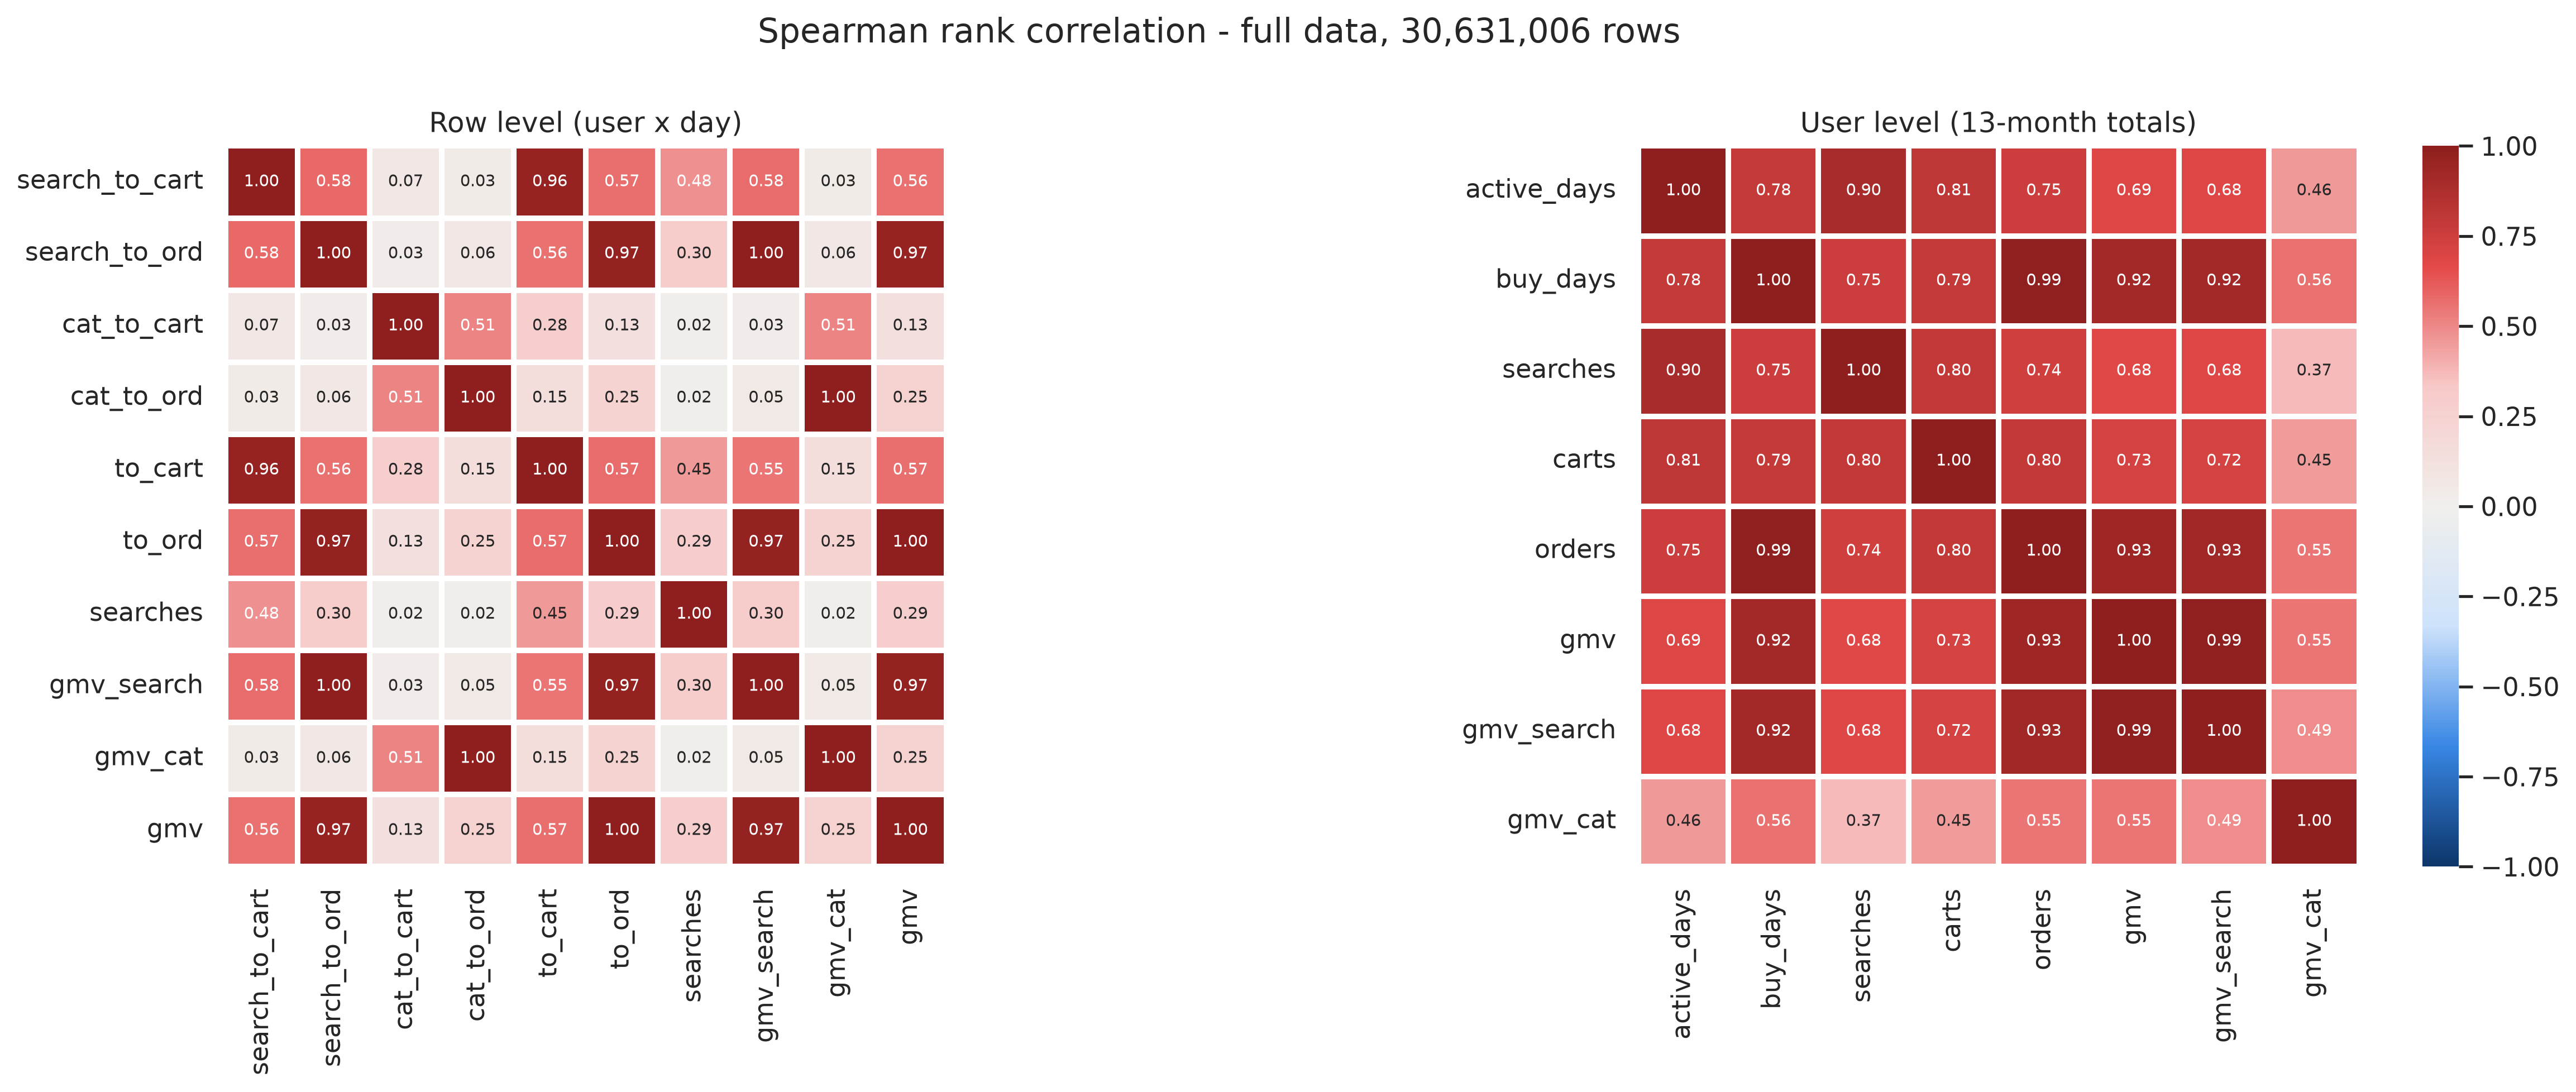

In [27]:
corr_cols = count_cols + money_cols
row_corr = df.select([pl.col(c).rank().alias(c) for c in corr_cols]).corr().to_numpy()

user_cols = [
    "active_days",
    "buy_days",
    "searches",
    "carts",
    "orders",
    "gmv",
    "gmv_search",
    "gmv_cat",
]
user_corr = users.select([pl.col(c).rank().alias(c) for c in user_cols]).corr().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, mat_c, labels, title in [
    (axes[0], row_corr, corr_cols, "Row level (user x day)"),
    (axes[1], user_corr, user_cols, "User level (13-month totals)"),
]:
    sns.heatmap(
        mat_c,
        annot=True,
        fmt=".2f",
        cmap=cmap_div,
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=2,
        linecolor="white",
        xticklabels=labels,
        yticklabels=labels,
        cbar=ax is axes[1],
        annot_kws={"size": 7},
        ax=ax,
    )
    ax.set_title(title)
fig.suptitle(f"Spearman rank correlation - full data, {df.height:,} rows", y=1.0)
plt.tight_layout()
plt.show()

## 13. Удержание

In [28]:
gaps = (
    df.select("user_id", "event_date")
    .sort("user_id", "event_date")
    .with_columns(gap=pl.col("event_date").diff().dt.total_days().over("user_id"))
    .drop_nulls("gap")
)
gap_hist = (
    gaps.with_columns(pl.col("gap").clip(upper_bound=31))
    .group_by("gap")
    .len()
    .sort("gap")
    .with_columns(share=pl.col("len") / gaps.height)
)

fig = px.bar(
    gap_hist,
    x="gap",
    y="share",
    color_discrete_sequence=[CAT[0]],
    labels={
        "gap": "days between consecutive active days (31 = 31 or more)",
        "share": "share of gaps",
    },
    title="Gap between consecutive visits",
)
fig.update_traces(marker_cornerradius=3, hovertemplate="%{x} days<br>%{y:.2%}<extra></extra>")
fig.update_layout(height=400, yaxis_tickformat=".0%", bargap=0.2)
fig.show()

print(f"median gap: {gaps['gap'].median():.0f} d | p90: {gaps['gap'].quantile(0.9):.0f} d")
print(f"share of gaps == 1 day: {(gaps['gap'] == 1).mean():.1%}")

median gap: 1 d | p90: 6 d
share of gaps == 1 day: 55.6%


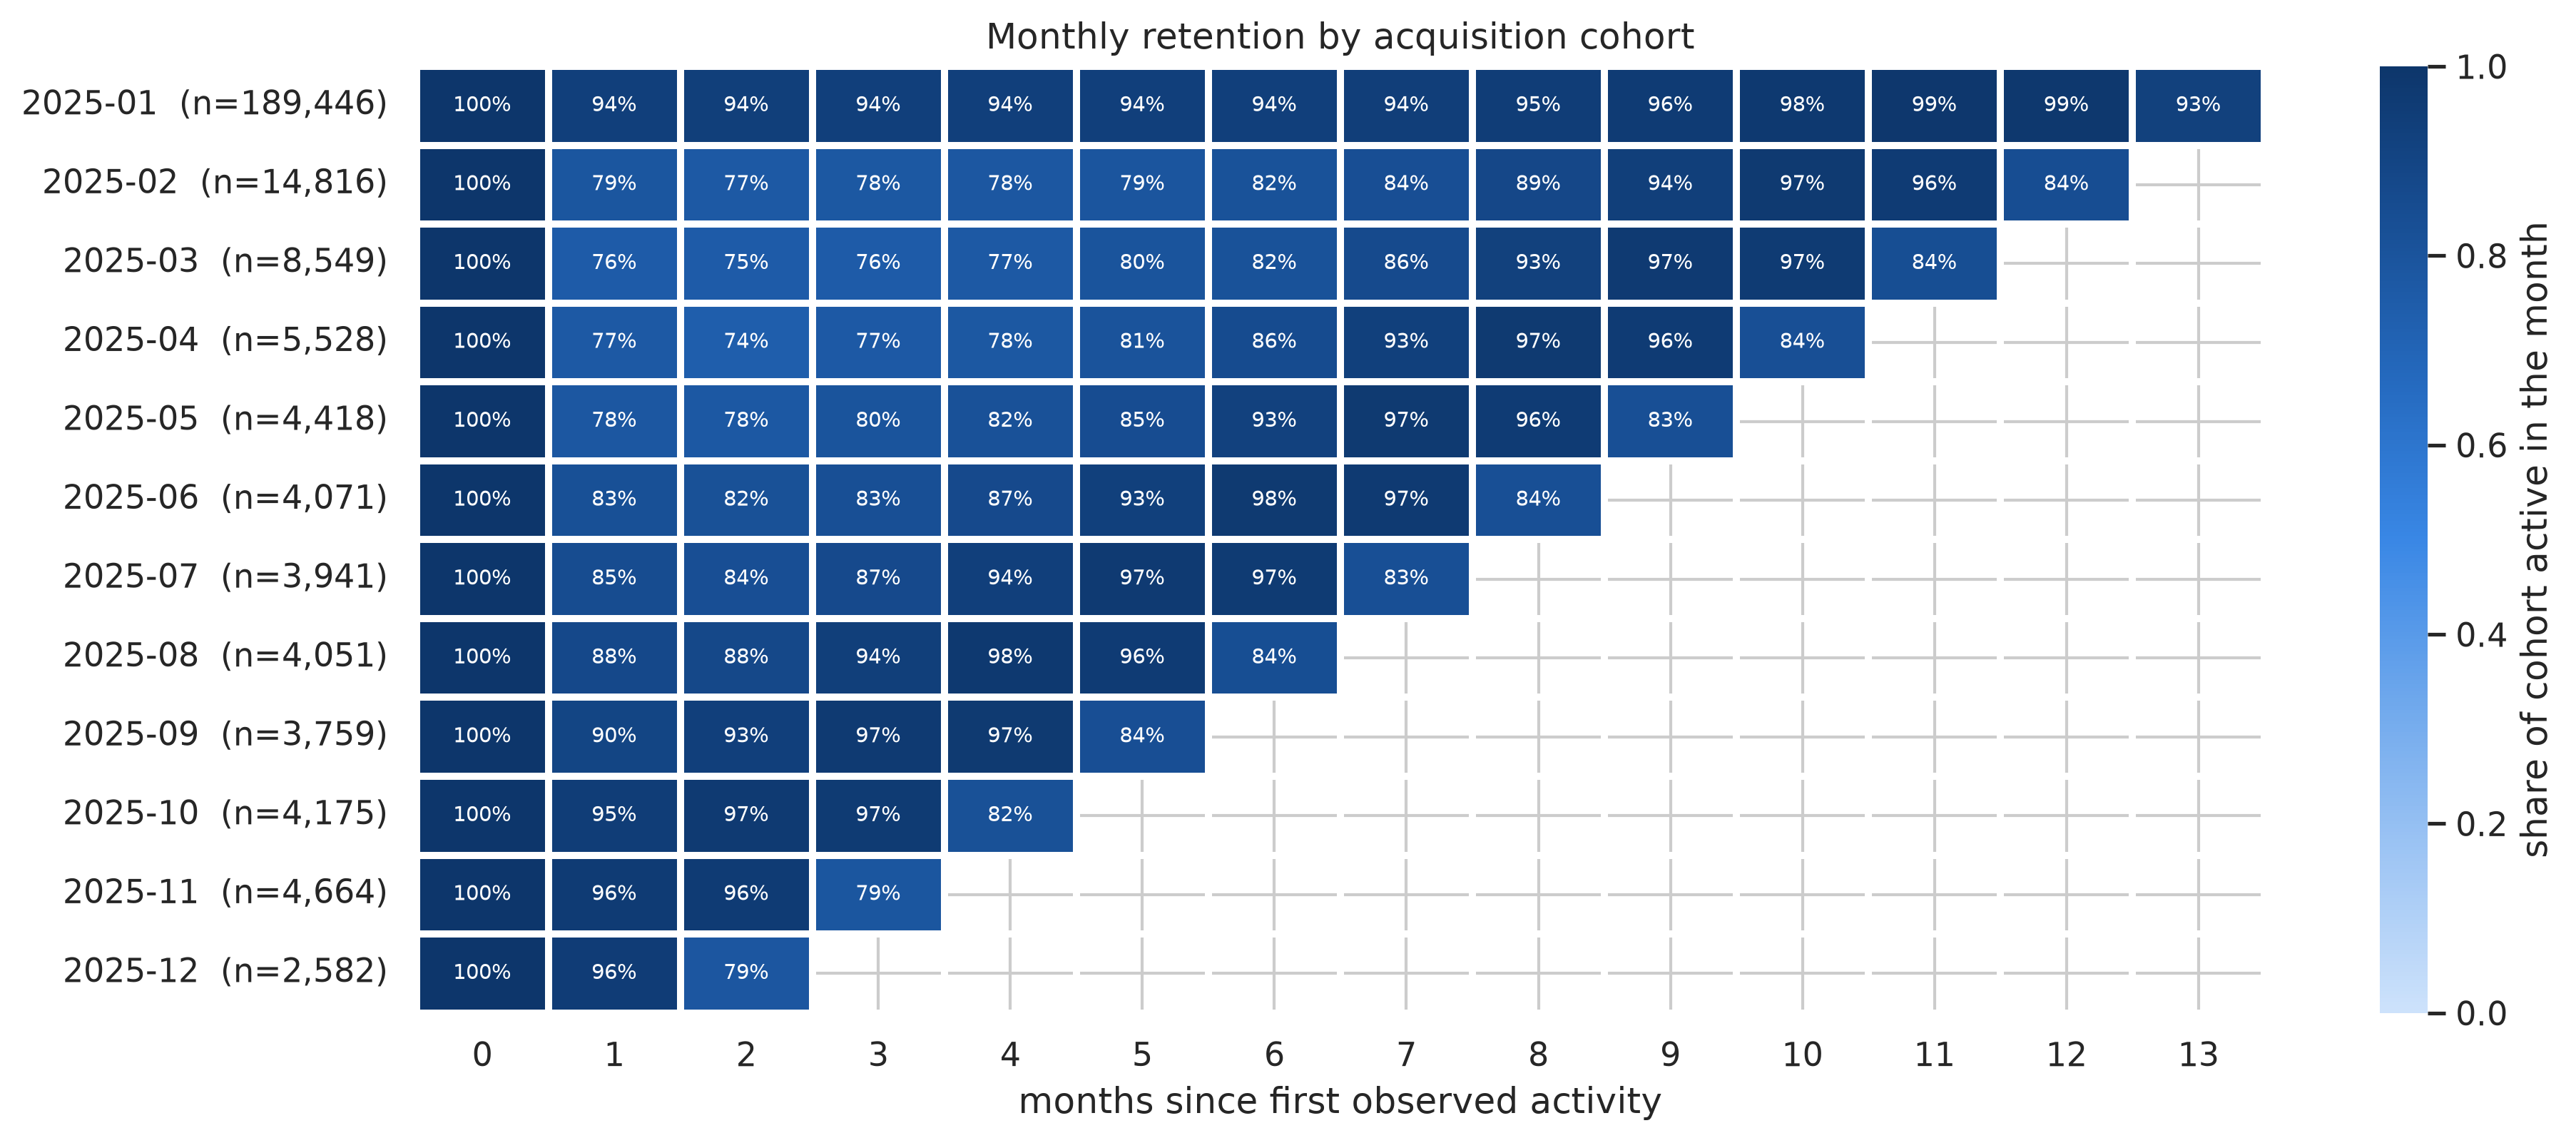

In [29]:
cohorts = users.select("user_id", cohort=pl.col("first_seen").dt.truncate("1mo"))
monthly = (
    df.select("user_id", month=pl.col("event_date").dt.truncate("1mo"))
    .unique()
    .join(cohorts, on="user_id")
    .with_columns(
        k=(pl.col("month").dt.year() - pl.col("cohort").dt.year()) * 12
        + pl.col("month").dt.month()
        - pl.col("cohort").dt.month()
    )
)
sizes = cohorts.group_by("cohort").len().rename({"len": "cohort_size"}).sort("cohort")
retention = (
    monthly.group_by("cohort", "k")
    .len()
    .join(sizes, on="cohort")
    .with_columns(rate=pl.col("len") / pl.col("cohort_size"))
    .pivot(on="k", index="cohort", values="rate")
    .sort("cohort")
)
ks = sorted(int(c) for c in retention.columns if c != "cohort")
ret_mat = retention.select([str(k) for k in ks]).to_numpy()
row_labels = [
    f"{c:%Y-%m}  (n={n:,})"
    for c, n in zip(sizes["cohort"].to_list(), sizes["cohort_size"].to_list(), strict=False)
]

plt.figure(figsize=(13, 5.5))
sns.heatmap(
    ret_mat,
    annot=True,
    fmt=".0%",
    cmap=cmap_seq,
    vmin=0,
    vmax=1,
    linewidths=2,
    linecolor="white",
    xticklabels=ks,
    yticklabels=row_labels,
    annot_kws={"size": 7},
    cbar_kws={"label": "share of cohort active in the month"},
)
plt.title("Monthly retention by acquisition cohort")
plt.xlabel("months since first observed activity")
plt.ylabel("")
plt.tight_layout()
plt.show()

Удержание не падает: оно слегка проседает, а затем растёт обратно до 96-99% у каждой когорты по мере приближения к концу окна. У настоящего маркетплейса форма обратная - монотонное затухание.

Это та же селекция из раздела 6, только нарисованная с помощью heatmap: пользователи, которые ушли бы, в выборку просто не попали. Последнее число в каждой строке занижено искусственно - февраль 2026 покрыт только на 13 дней.


## 14. Выбросы и аномалии

In [30]:
anomaly = (
    daily.select("event_date", "gmv", "active_users", "gmv_per_active")
    .with_columns(baseline=pl.col("gmv").rolling_median(29, center=True, min_samples=5))
    .with_columns(deviation=pl.col("gmv") / pl.col("baseline") - 1)
)

fig = px.bar(
    anomaly,
    x="event_date",
    y="deviation",
    color_discrete_sequence=[CAT[0]],
    labels={"event_date": "", "deviation": "GMV vs 29-day centred median"},
    title="Calendar anomalies in daily GMV",
)
fig.update_traces(hovertemplate="%{x|%Y-%m-%d}<br>%{y:+.1%}<extra></extra>")
fig.update_layout(height=400, yaxis_tickformat="+.0%")
fig.show()

anomaly.filter(pl.col("deviation").abs() > 0.15).select(
    "event_date", "gmv", "active_users", "deviation"
).sort("deviation")

event_date,gmv,active_users,deviation
date,f64,u32,f64
2025-12-31,526653.977416,57419,-0.290076
2026-01-01,554163.773539,69140,-0.252993
2025-05-09,430799.609461,52427,-0.23294
2025-01-01,374066.469016,43516,-0.215029
2026-01-24,569366.146659,91307,-0.183583
2025-10-15,875277.869143,86805,0.157453
2025-05-20,675175.433835,69730,0.158647
2025-04-27,655506.248916,68623,0.164775
2025-05-13,655584.324298,68070,0.164914


In [31]:
print("largest single user-day GMV values")
print(
    df.sort("gmv", descending=True)
    .head(5)
    .select("user_id", "event_date", "gmv", "to_ord", "to_cart", "searches")
)
print()
print("heaviest users over the full window")
print(
    users.sort("gmv", descending=True)
    .head(5)
    .select("user_id", "gmv", "orders", "active_days", "aov")
)
print()
print(f"single largest user-day = {gmv_rows.max() / gmv_rows.sum():.4%} of all GMV")
print(f"top-100 users          = {ranked_gmv[:100].sum() / users_gmv.sum():.2%} of all GMV")
print(f"users without a single order = {(users['orders'].to_numpy() == 0).mean():.2%}")

largest single user-day GMV values


shape: (5, 6)
┌─────────┬────────────┬──────────────┬────────┬─────────┬──────────┐
│ user_id ┆ event_date ┆ gmv          ┆ to_ord ┆ to_cart ┆ searches │
│ ---     ┆ ---        ┆ ---          ┆ ---    ┆ ---     ┆ ---      │
│ i32     ┆ date       ┆ f64          ┆ i16    ┆ i16     ┆ i16      │
╞═════════╪════════════╪══════════════╪════════╪═════════╪══════════╡
│ 897238  ┆ 2025-05-10 ┆ 73830.297037 ┆ 1      ┆ 1       ┆ 3        │
│ 642061  ┆ 2025-11-17 ┆ 56466.96481  ┆ 2      ┆ 32      ┆ 7        │
│ 587676  ┆ 2025-03-28 ┆ 37740.934942 ┆ 2      ┆ 2       ┆ 5        │
│ 587676  ┆ 2025-01-15 ┆ 34984.353504 ┆ 2      ┆ 2       ┆ 1        │
│ 747516  ┆ 2025-05-19 ┆ 30453.121944 ┆ 3      ┆ 5       ┆ 4        │
└─────────┴────────────┴──────────────┴────────┴─────────┴──────────┘

heaviest users over the full window
shape: (5, 5)
┌─────────┬───────────────┬────────┬─────────────┬─────────────┐
│ user_id ┆ gmv           ┆ orders ┆ active_days ┆ aov         │
│ ---     ┆ ---           ┆ ---    

## 15. Целевая переменная

In [ ]:


user_index = df.select("user_id").unique().sort("user_id")
last_anchor = d_max - timedelta(days=horizon_days)
anchor_stride = 14
anchors = sorted(last_anchor - timedelta(days=anchor_stride * i) for i in range(4))


def window_sum(start: date, end: date, col: str = "gmv") -> np.ndarray:
    agg = (
        df.filter(pl.col("event_date").is_between(start, end))
        .group_by("user_id")
        .agg(pl.col(col).sum().alias("value"))
    )
    joined = user_index.join(agg, on="user_id", how="left").with_columns(
        pl.col("value").fill_null(0.0)
    )
    return joined["value"].to_numpy()


def target_at(anchor: date) -> np.ndarray:
    return window_sum(anchor + timedelta(days=1), anchor + timedelta(days=horizon_days))


rows = []
for a in anchors:
    t = target_at(a)
    rows.append(
        {
            "anchor": a,
            "target window": f"{a + timedelta(days=1)} .. {a + timedelta(days=horizon_days)}",
            "zero share": float((t == 0).mean()),
            "mean": float(t.mean()),
            "median | positive": float(np.quantile(t[t > 0], 0.5)),
            "p99": float(np.quantile(t, 0.99)),
            "max": float(t.max()),
            "top 1% of users": float(np.sort(t)[::-1][: t.size // 100].sum() / t.sum()),
        }
    )
pl.DataFrame(rows)

anchor,target window,zero share,mean,median | positive,p99,max,top 1% of users
date,str,f64,f64,f64,f64,f64,f64
2025-12-03,"""2025-12-04 .. 2026-01-02""",0.424488,110.036913,78.056297,1279.235584,24577.45826,0.204689
2025-12-17,"""2025-12-18 .. 2026-01-16""",0.440304,99.231075,71.239355,1186.436591,29817.177691,0.211856
2025-12-31,"""2026-01-01 .. 2026-01-30""",0.464456,84.575171,61.76602,1045.411221,49686.300334,0.225789
2026-01-14,"""2026-01-15 .. 2026-02-13""",0.45934,84.034042,61.35894,1040.137311,53746.950812,0.222493


In [33]:
y = target_at(last_anchor)
prev_30d = window_sum(last_anchor - timedelta(days=horizon_days - 1), last_anchor)

transitions = {
    "no gmv -> no gmv": (prev_30d == 0) & (y == 0),
    "no gmv -> buys": (prev_30d == 0) & (y > 0),
    "buys -> no gmv": (prev_30d > 0) & (y == 0),
    "buys -> buys": (prev_30d > 0) & (y > 0),
}
pl.DataFrame(
    {
        "segment": list(transitions),
        "share of users": [float(m.mean()) for m in transitions.values()],
        "share of target gmv": [float(y[m].sum() / y.sum()) for m in transitions.values()],
    }
)

segment,share of users,share of target gmv
str,f64,f64
"""no gmv -> no gmv""",0.31524,0.0
"""no gmv -> buys""",0.12168,0.119538
"""buys -> no gmv""",0.1441,0.0
"""buys -> buys""",0.41898,0.880462


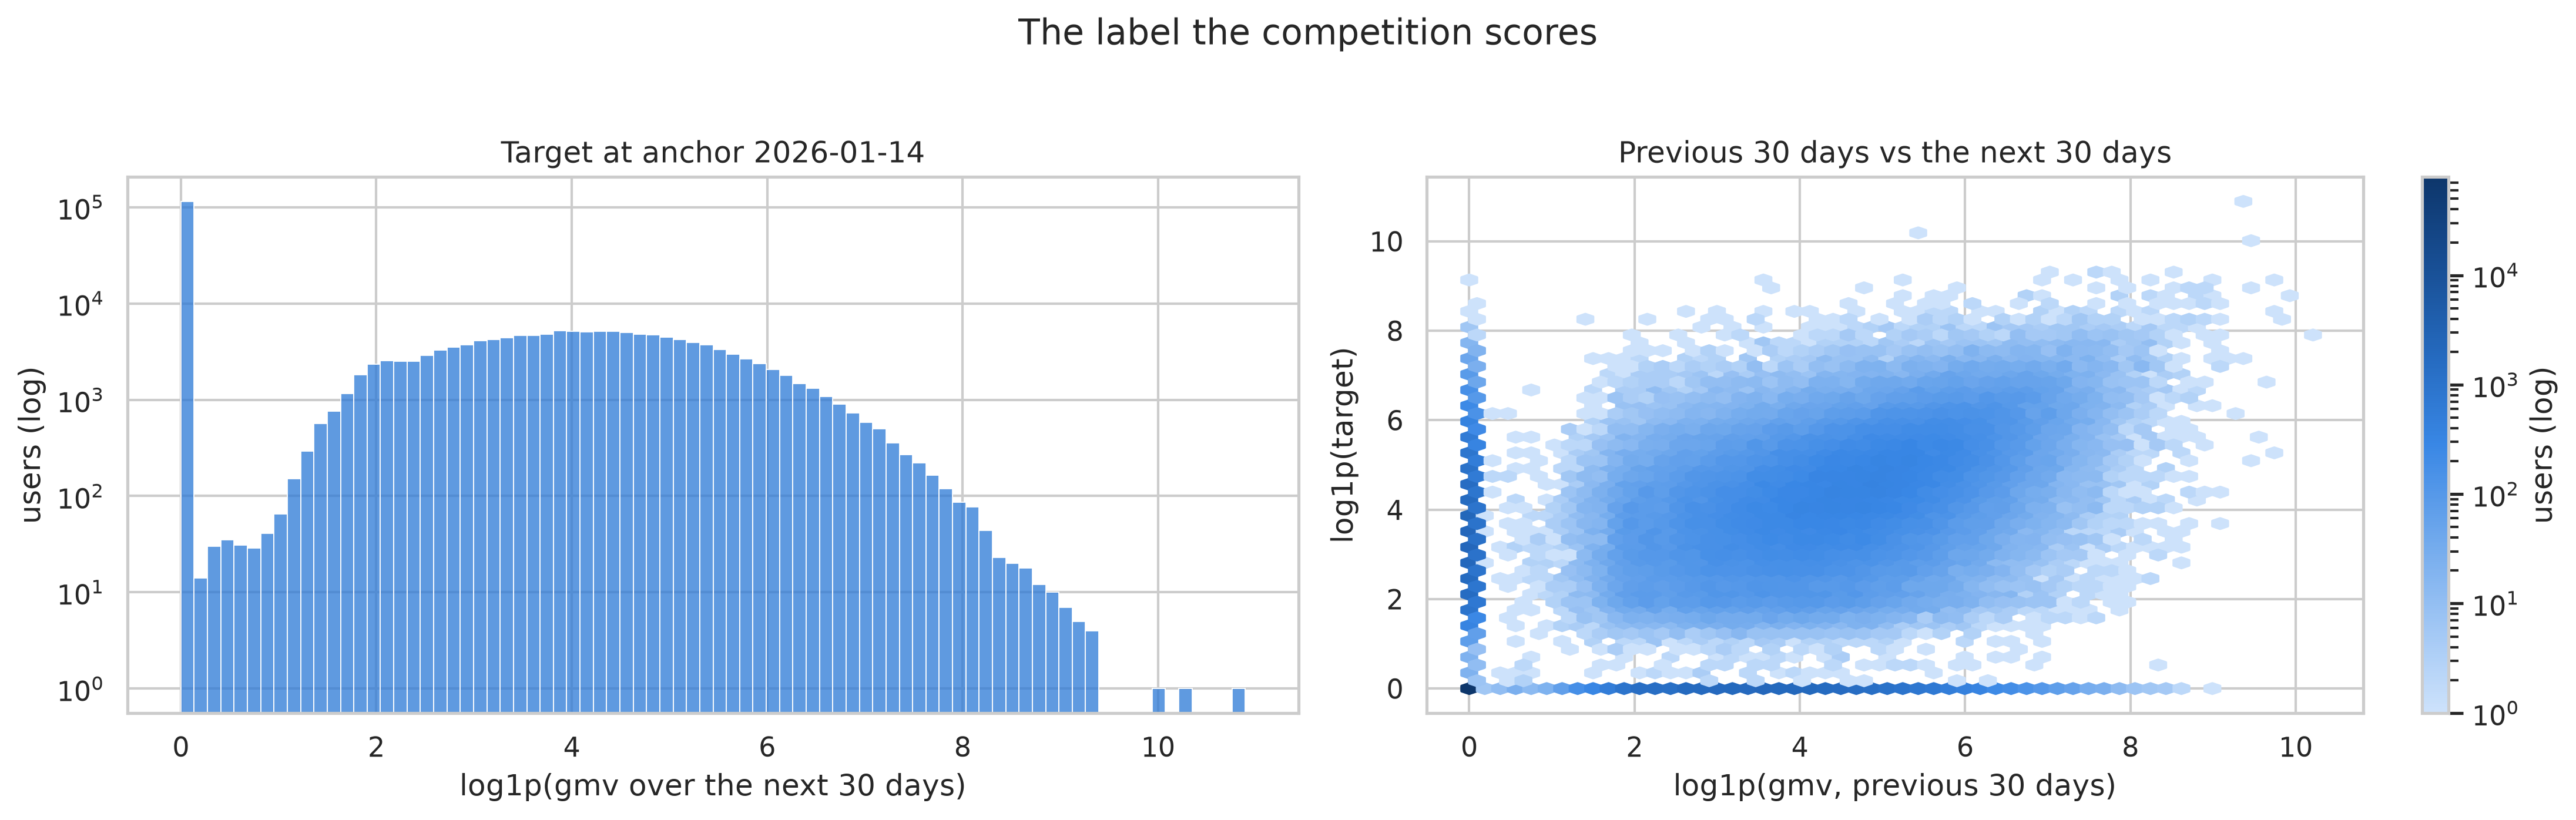

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.histplot(np.log1p(y), bins=80, color=CAT[0], ax=axes[0])
axes[0].set(
    title=f"Target at anchor {last_anchor}",
    xlabel="log1p(gmv over the next 30 days)",
    ylabel="users (log)",
    yscale="log",
)
hb = axes[1].hexbin(
    np.log1p(prev_30d), np.log1p(y), gridsize=55, bins="log", cmap=cmap_seq, mincnt=1
)
axes[1].set(
    title="Previous 30 days vs the next 30 days",
    xlabel="log1p(gmv, previous 30 days)",
    ylabel="log1p(target)",
)
fig.colorbar(hb, ax=axes[1], label="users (log)")
fig.suptitle("The label the competition scores", y=1.03)
plt.tight_layout()
plt.show()

## 16. RMSLE

In [35]:
def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    log_true = np.log1p(np.clip(y_true, 0, None))
    log_pred = np.log1p(np.clip(y_pred, 0, None))
    return float(np.sqrt(np.mean((log_true - log_pred) ** 2)))


def value_buckets(values: np.ndarray, edges: list[float]) -> dict[str, np.ndarray]:
    buckets = {"0": values == 0}
    for i, hi in enumerate(edges):
        lo = 0.0 if i == 0 else edges[i - 1]
        buckets[f"({lo:g}, {hi:g}]"] = (values > lo) & (values <= hi)
    buckets[f"> {edges[-1]:g}"] = values > edges[-1]
    return buckets


geometric_mean = float(np.expm1(np.log1p(y).mean()))
constants = {
    "zero": 0.0,
    "median": float(np.median(y)),
    "arithmetic mean": float(y.mean()),
    "geometric mean": geometric_mean,
}
pl.DataFrame(
    {
        "constant prediction": list(constants),
        "value": list(constants.values()),
        "rmsle": [rmsle(y, np.full_like(y, c)) for c in constants.values()],
    }
)

constant prediction,value,rmsle
str,f64,f64
"""zero""",0.0,3.203637
"""median""",7.892408,2.289
"""arithmetic mean""",84.034042,3.174976
"""geometric mean""",8.413067,2.288292


In [36]:
grid = np.logspace(-1, 3.2, 160)
curve = [rmsle(y, np.full_like(y, c)) for c in grid]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=grid,
        y=curve,
        mode="lines",
        line={"color": CAT[0], "width": 2},
        name="constant prediction",
        hovertemplate="predict %{x:,.1f}<br>rmsle %{y:.4f}<extra></extra>",
    )
)
for value, label, color in [
    (geometric_mean, "geometric mean", CAT[2]),
    (float(y.mean()), "arithmetic mean", CAT[1]),
]:
    fig.add_vline(
        x=value,
        line_color=color,
        line_dash="dash",
        annotation_text=f"{label} = {value:,.1f}",
    )
fig.add_hline(y=rmsle(y, np.zeros_like(y)), line_color=GREY, line_dash="dot")
fig.update_layout(
    height=430,
    title="RMSLE of a constant prediction (dotted line = predicting zero)",
    xaxis={"title": "constant", "type": "log"},
    yaxis={"title": "rmsle"},
    showlegend=False,
)
fig.show()

In [37]:
squared_error = (np.log1p(y) - np.log1p(geometric_mean)) ** 2
target_buckets = value_buckets(y, [10.0, 50.0, 200.0, 1000.0])

decomposition = pl.DataFrame(
    {
        "target": list(target_buckets),
        "share of users": [float(m.mean()) for m in target_buckets.values()],
        "share of squared error": [
            float(squared_error[m].sum() / squared_error.sum()) for m in target_buckets.values()
        ],
    }
)

fig = px.bar(
    decomposition.unpivot(index="target", variable_name="metric", value_name="share"),
    x="target",
    y="share",
    color="metric",
    barmode="group",
    text_auto=".1%",
    color_discrete_sequence=[CAT[0], CAT[1]],
    labels={"target": "target bucket", "share": "", "metric": ""},
    title="Where the error of the best constant prediction comes from",
)
fig.update_traces(marker_cornerradius=4)
fig.update_layout(height=420, yaxis_tickformat=".0%", bargap=0.3)
fig.show()

decomposition

target,share of users,share of squared error
str,f64,f64
"""0""",0.45934,0.440982
"""(0, 10]""",0.056432,0.002629
"""(10, 50]""",0.183384,0.04159
"""(50, 200]""",0.192356,0.207523
"""(200, 1000]""",0.0976,0.252212
"""> 1000""",0.010888,0.055065


## 17. GMV с временем

In [38]:
history_windows = [7, 14, 30, 60, 90]
history = {}
for w in history_windows:
    start = last_anchor - timedelta(days=w - 1)
    history[f"gmv_{w}d"] = window_sum(start, last_anchor)
    history[f"to_ord_{w}d"] = window_sum(start, last_anchor, col="to_ord")

log_target = np.log1p(y)
pl.DataFrame(
    {
        "history window": [f"{w}d" for w in history_windows],
        "corr with gmv": [
            float(np.corrcoef(log_target, np.log1p(history[f"gmv_{w}d"]))[0, 1])
            for w in history_windows
        ],
        "corr with to_ord": [
            float(np.corrcoef(log_target, np.log1p(history[f"to_ord_{w}d"]))[0, 1])
            for w in history_windows
        ],
    }
)

history window,corr with gmv,corr with to_ord
str,f64,f64
"""7d""",0.422656,0.429305
"""14d""",0.488345,0.500355
"""30d""",0.556968,0.585951
"""60d""",0.58602,0.631873
"""90d""",0.58937,0.64342


In [39]:
prev_buckets = value_buckets(prev_30d, [10.0, 50.0, 200.0, 1000.0])
by_bucket = pl.DataFrame(
    {
        "previous 30d gmv": list(prev_buckets),
        "share of users": [float(m.mean()) for m in prev_buckets.values()],
        "target zero rate": [float((y[m] == 0).mean()) for m in prev_buckets.values()],
        "target geometric mean": [
            float(np.expm1(np.log1p(y[m]).mean())) for m in prev_buckets.values()
        ],
        "target arithmetic mean": [float(y[m].mean()) for m in prev_buckets.values()],
    }
)

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Bar(
        x=by_bucket["previous 30d gmv"],
        y=by_bucket["target zero rate"],
        marker_color=CAT[0],
        name="target zero rate",
        hovertemplate="%{x}<br>%{y:.1%}<extra></extra>",
    ),
    secondary_y=False,
)
for col, color in [("target geometric mean", CAT[1]), ("target arithmetic mean", CAT[3])]:
    fig.add_trace(
        go.Scatter(
            x=by_bucket["previous 30d gmv"],
            y=by_bucket[col],
            mode="lines+markers",
            line={"color": color, "width": 2},
            name=col,
            hovertemplate="%{x}<br>%{y:,.1f}<extra></extra>",
        ),
        secondary_y=True,
    )
fig.update_layout(
    height=440,
    title="Next-30-day target by previous-30-day GMV",
    xaxis_title="previous 30d gmv",
    legend={"orientation": "h", "y": -0.2},
)
fig.update_yaxes(title_text="target zero rate", tickformat=".0%", secondary_y=False)
fig.update_yaxes(title_text="target, gmv", type="log", secondary_y=True)
fig.show()

by_bucket

previous 30d gmv,share of users,target zero rate,target geometric mean,target arithmetic mean
str,f64,f64,f64,f64
"""0""",0.43692,0.721505,1.714744,22.991147
"""(0, 10]""",0.04932,0.436577,6.142767,40.205872
"""(10, 50]""",0.176696,0.352357,10.688062,58.831982
"""(50, 200]""",0.203764,0.221688,26.493444,107.806217
"""(200, 1000]""",0.118816,0.1182,78.890897,245.881405
"""> 1000""",0.014484,0.075394,226.468326,720.018575


In [40]:
shrinkage = np.arange(0.05, 1.55, 0.05)
shrunk_scores = [rmsle(y, k * history["gmv_30d"]) for k in shrinkage]
best_k = float(shrinkage[int(np.argmin(shrunk_scores))])

naive = {
    "zero": np.zeros_like(y),
    "geometric mean constant": np.full_like(y, geometric_mean),
    "previous 30d gmv": history["gmv_30d"],
    "previous 90d gmv / 3": history["gmv_90d"] / 3.0,
    f"{best_k:.2f} x previous 30d gmv": best_k * history["gmv_30d"],
}

fig = px.line(
    x=shrinkage,
    y=shrunk_scores,
    color_discrete_sequence=[CAT[0]],
    labels={"x": "multiplier on previous 30d gmv", "y": "rmsle"},
    title="Carrying the previous 30 days forward has to be shrunk",
)
fig.update_traces(line_width=2, hovertemplate="k = %{x:.2f}<br>rmsle %{y:.4f}<extra></extra>")
fig.add_vline(x=best_k, line_color=CAT[1], line_dash="dash", annotation_text=f"k = {best_k:.2f}")
fig.update_layout(height=400)
fig.show()

pl.DataFrame(
    {
        "baseline": list(naive),
        "rmsle": [rmsle(y, p) for p in naive.values()],
    }
).sort("rmsle")

baseline,rmsle
str,f64
"""0.30 x previous 30d gmv""",2.028094
"""previous 90d gmv / 3""",2.093552
"""previous 30d gmv""",2.195065
"""geometric mean constant""",2.288292
"""zero""",3.203637


## 18. Календарь горизонта прогнозирования

In [41]:
last_year_start = target_start.replace(year=target_start.year - 1)
last_year_end = target_end.replace(year=target_end.year - 1)


def window_profile(start: date, end: date, label: str) -> dict[str, object]:
    w = daily.filter(pl.col("event_date").is_between(start, end))
    return {
        "window": label,
        "dates": f"{start} .. {end}",
        "gmv per active user": float(w["gmv_per_active"].mean()),
        "buyer rate": float(w["buyer_rate"].mean()),
    }


profiles = [
    window_profile(
        last_year_start - timedelta(days=30),
        last_year_start - timedelta(days=1),
        "2025: 30 days before",
    ),
    window_profile(last_year_start, last_year_end, "2025: same calendar window"),
]
profiles += [
    window_profile(a + timedelta(days=1), a + timedelta(days=horizon_days), f"cv anchor {a}")
    for a in anchors
]
profiles.append(
    window_profile(d_max - timedelta(days=horizon_days - 1), d_max, "last observed 30d")
)

windows_df = pl.DataFrame(profiles)
calendar_factor = (
    windows_df.filter(pl.col("window") == "2025: same calendar window")[
        "gmv per active user"
    ].item()
    / windows_df.filter(pl.col("window") == "2025: 30 days before")["gmv per active user"].item()
)
print(f"target window {target_start} .. {target_end}")
print(f"calendar factor measured on 2025: {calendar_factor:.4f}")
windows_df

target window 2026-02-14 .. 2026-03-15
calendar factor measured on 2025: 1.0896


window,dates,gmv per active user,buyer rate
str,str,f64,f64
"""2025: 30 days before""","""2025-01-15 .. 2025-02-13""",8.094519,0.136123
"""2025: same calendar window""","""2025-02-14 .. 2025-03-15""",8.819522,0.146944
"""cv anchor 2025-12-03""","""2025-12-04 .. 2026-01-02""",9.697831,0.165397
"""cv anchor 2025-12-17""","""2025-12-18 .. 2026-01-16""",9.18514,0.162271
"""cv anchor 2025-12-31""","""2026-01-01 .. 2026-01-30""",7.827929,0.150638
"""cv anchor 2026-01-14""","""2026-01-15 .. 2026-02-13""",7.51809,0.149223
"""last observed 30d""","""2026-01-15 .. 2026-02-13""",7.51809,0.149223


In [42]:
drift = (
    daily.select("event_date", "gmv_per_active")
    .with_columns(mean_30d=pl.col("gmv_per_active").rolling_mean(30))
    .with_columns(ratio=pl.col("mean_30d") / pl.col("mean_30d").shift(30))
    .drop_nulls("ratio")
)
ratios = drift["ratio"].to_numpy()
print(
    f"ratio of neighbouring 30-day windows: median {np.median(ratios):.3f}, "
    f"p10 {np.quantile(ratios, 0.1):.3f}, p90 {np.quantile(ratios, 0.9):.3f}"
)
print(f"calendar factor percentile: {float((ratios < calendar_factor).mean()):.1%}")

season = daily.filter(pl.col("event_date").is_between(last_year_start, last_year_end)).with_columns(
    deviation=pl.col("gmv_per_active") / pl.col("gmv_per_active").mean() - 1
)

fig = px.bar(
    season,
    x="event_date",
    y="deviation",
    color_discrete_sequence=[CAT[0]],
    labels={"event_date": "", "deviation": "vs the window average"},
    title=f"Daily GMV per active user inside {last_year_start} .. {last_year_end}",
)
fig.update_traces(hovertemplate="%{x|%Y-%m-%d}<br>%{y:+.1%}<extra></extra>")
fig.update_layout(height=400, yaxis_tickformat="+.0%")
fig.show()

season.sort("deviation", descending=True).select("event_date", "gmv_per_active", "deviation").head(
    8
)

ratio of neighbouring 30-day windows: median 1.017, p10 0.938, p90 1.068
calendar factor percentile: 94.6%


event_date,gmv_per_active,deviation
date,f64,f64
2025-03-03,9.855578,0.117473
2025-03-01,9.716917,0.101751
2025-03-06,9.702388,0.100104
2025-03-08,9.402743,0.066128
2025-02-28,9.248432,0.048632
2025-03-05,9.088732,0.030524
2025-03-15,9.086423,0.030262
2025-03-10,9.027816,0.023617


## Выводы

**Структура данных**
* Ровно одна строка на пару `(user_id, event_date)`, дублей и пропусков нет. Полная сетка пользователь x день заполнена лишь на ~30%, то есть строка существует только для дней с активностью - «нулевые» дни надо достраивать явно.
* Из 16 признаковых колонок независимых меньше половины. Точно выполняются тождества `gmv = gmv_search + gmv_cat`, `to_cart = search_to_cart + cat_to_cart`, `to_ord = search_to_ord + cat_to_ord`, все шесть `has_*` - индикаторы соответствующих счётчиков, `search = [searches > 0]`. Единственный неизбыточный флаг - `cat`: по описанию это «флаг пользования Каталогом», и он совпадает с `cat_to_cart + cat_to_ord > 0` лишь на 86.8% строк - то есть фиксирует и заходы в каталог без корзины и заказа.
* GMV возникает только в дни с заказом: `gmv > 0` взаимно однозначен `to_ord > 0` (и тоже по каналам). Значит задача распадается на две - вероятность покупки и величина чека.

**Главный риск - это смещение выборки**
* Ни у одного пользователя последняя активность не раньше 2026-01-15. То есть все 250k активны хотя бы раз в последние 30 дней. И ни один не появляется позже 2025-12-15, то есть у всех есть минимум ~60 дней истории. Выборка отобрана по выживанию.
* Отсюда рост DAU с 43k до 95k при плоских GMV на активного пользователя (~8-9) и доле покупателей (~0.14-0.16). Это последствие отбора, а не рост площадки: чем ближе день к концу окна, тем выше шанс увидеть отобранного пользователя активным.
* Когортный heatmap показывает то же самое: удержание не падает, а растёт почти до 100% к концу окна.
* Следовательно, любой исторический срез тем «беднее», чем он раньше. И не потому, что площадка росла, а потому что так устроен отбор. Вне этой выборки условие «активен в последние 30 дней» не действует, поэтому доля неактивных и неплатящих среди реальных пользователей выше, чем здесь.

**Распределения**
* Много пропусков на всех уровнях: 84.5% строк без GMV, 63% без корзины, 12.3% пользователей не купили ничего за все 13 месяцев.
* Ненулевой GMV логнормален: медиана дневного GMV в дни с заказом 23.3, p99 557, максимум 73 830. Концентрация высокая - Gini ≈ 0.70, топ-1% пользователей дают 14.9% GMV, топ-10% - 53.0%, топ-50% - 94.8%. Хвост очень тяжёлый, поэтому средние по пользователям малоинформативны - смотреть надо в логарифмической шкале и по квантилям.
* Каналы сильно перекошены: поиск даёт ~93% GMV, каталог ~7%; доля каталога устойчива во времени, так что отдельные признаки по каналам полезны, но объём сигнала в них невелик. При этом сочетание `search=1, cat=1` - самый «горячий» день: 17.3 GMV на строку и 24.4% дней с заказом против 9.7 и 17.9% для чистого поиска.

**Время**
* Недельная сезонность слабая и нестабильная по знаку: летом самый слабый день - суббота (0.90-0.92 от среднего дня месяца), а в декабре выходные становятся самыми сильными (1.05-1.07). Календарная сезонность гораздо сильнее недельной. Максимум GMV приходится на 20-28 декабря, провалы - 31 декабря и 1 января (-29% и -25% к скользящей медиане), 9 мая (-23%), 1 января 2025 (-22%); всплеск 11 ноября (+19%) - распродажа 11.11. 30-дневное окно, накрывающее декабрь, несопоставимо с февральским, поэтому месячные  и 30-дневные срезы нельзя сравнивать без календарной поправки.
* Пользователи ходят часто: медианный разрыв между визитами - 1 день, 55.6% разрывов равны одному дню, 81% укладываются в три дня, но p99 = 26 дней. Recency-признаки (дни с последней активности/покупки) отделяют сегменты лучше любых объёмных агрегатов.

**Целевая переменная и метрика**
* Целевая переменная - сумма `gmv` за 30 дней после якорной даты; для сабмита якорь 2026-02-13, окно 2026-02-14 ... 2026-03-15. На последнем реализуемом якоре (2026-01-14) ровно ноль у 45.9% пользователей, средний таргет 84.0, медиана среди ненулевых 61.4, p99 = 1040, максимум 53 747, топ-1% пользователей дают 22.2% суммы. Доля нулей зависит от календаря окна: 42.4% на якоре 2025-12-03 против 46.4% на 2025-12-31.
* История переносится в будущее лишь частично: у 12.2% пользователей за прошлые 30 дней нет ни одной покупки, но в целевом окне они покупают - это 12.0% всего таргетного GMV; ещё 14.4% наоборот перестают покупать. Корреляция log1p таргета с log1p истории растёт с длиной окна и выше для счётчика заказов, чем для денег: `to_ord` 0.59 (30 дней) и 0.64 (90 дней) против `gmv` 0.56 и 0.59.
* Метрика логарифмическая, поэтому оптимальная константа - не среднее (84.0, RMSLE 3.175), а expm1(mean(log1p(y))) = 8.4 (RMSLE 2.288); прогноз нулями даёт 3.204. Прямой перенос прошлых 30 дней - 2.195, он же со сжатием в 0.30 раза - 2.028. Оптимум внутри любого сегмента - геометрическое среднее: для пользователей с GMV 200-1000 за прошлые 30 дней это 79 против арифметических 246. Учить и калибровать модель нужно в log1p, а предсказания возвращать через expm1.
* Ошибка размазана по сегментам, а не сосредоточена на нулях: пользователи с нулевым таргетом - 45.9% выборки и 44.1% квадратичной ошибки лучшей константы, сегмент 50-1000 - 29.0% выборки и 46.0% ошибки. Одной классификацией «купит/не купит» метрику не выиграть, величину чека надо предсказывать тоже.
* Календарь целевого окна не совпадает ни с одним окном валидации. Тот же интервал год назад (2025-02-14 ... 2025-03-15) дал GMV на активного пользователя на 9.0% выше предыдущих 30 дней - это 95-й процентиль обычного 30-дневного дрейфа (медиана +1.7%, p90 +6.8%): 14 февраля, 23 февраля и 8 марта поднимают окно.

**В общем**
* Из-за тождеств из п.2 независимых колонок всего восемь: `searches`, `search_to_cart`, `search_to_ord`, `cat_to_cart`, `cat_to_ord`, `gmv_search`, `gmv_cat` и `cat`. Остальные выводятся из них и дадут лишь дубли при анализе важности признаков.
* Агрегаты имеет смысл считать на нескольких окнах (7/30/60/90 дней) и дополнять их recency (дни с последней активности и с последней покупки), долей активных дней, долей дней с заказом и средним чеком: по разделу 16 визиты плотные (медианный разрыв - 1 день), но с тяжёлым хвостом до 26 дней на p99, то есть давность сильно варьируется между пользователями и сама по себе несёт информацию.
* Любое сравнение периодов между собой нужно делать с поправкой на два эффекта - отбор выборки завышает активность ближе к концу окна, а декабрьский пик и январский провал сдвигают месячные срезы.